In [1]:
%pip cache purge
%pip install -r ../requirements.txt


Files removed: 0 (0 bytes)
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.python.org/simple
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import os
import shutil
import random

import warnings
from time import time
import seaborn as sns
sns.set(rc={'figure.figsize':(12,8)})

# mne import
import mne
from mne import Epochs, pick_types, events_from_annotations
from mne.io import concatenate_raws
from mne.io.edf import read_raw_edf
from mne.datasets import eegbci
from mne.preprocessing import (ICA, create_eog_epochs, create_ecg_epochs, corrmap, Xdawn)
from mne.time_frequency import AverageTFR
from mne.channels import make_standard_montage
from mne.decoding import LinearModel, Vectorizer, get_coef, Scaler, CSP, SPoC, UnsupervisedSpatialFilter
# from mne.time_frequency import psd_welch
mne.set_log_level('WARNING')

import sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn import datasets
from sklearn.model_selection import train_test_split


Matplotlib is building the font cache; this may take a moment.


In [3]:
DIRECTORIES = [
    "../models", 
    # "../data/raw/files",
	"../plots",
]
deleted_files = []

for directory in DIRECTORIES:
    if not os.path.exists(directory):
        print(f"Directory '{directory}' does not exist.")
        continue

    for item in os.listdir(directory):
        item_path = os.path.join(directory, item)

        if item == ".gitkeep":
            continue  # Skip .gitkeep

        if os.path.isfile(item_path):
            os.remove(item_path)
            deleted_files.append(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
            deleted_files.append(item_path + "/")  

if deleted_files:
    print("Deleted files and directories:")
    for file in deleted_files:
        print(f" - {file}")
else:
    print("No files to delete.")


Deleted files and directories:
 - ../models/best_model.joblib
 - ../models/best_model_info.joblib
 - ../models/best_model_info.json
 - ../models/evaluated_model.joblib
 - ../models/evaluation_results.json


In [4]:
# subject = random.sample(range(1, 110), 5)  # 5 random and unique subjects
# subject.sort()

# experiments = [
#     [3, 7, 11],
#     [4, 8, 12],
#     [5, 9, 13],
#     [6, 10, 14]
# ]
# run_experiments = random.choice(experiments)

subjects = [1, 2, 3]
run_experiments = [5, 9, 13]

print(f"Subjects: {subjects}")
print(f"Experiments: {run_experiments}")


Subjects: [1, 2, 3]
Experiments: [5, 9, 13]


In [5]:
raw_files = []

for person_number in subjects:
    for i in run_experiments:
        raw_files_experiments = [read_raw_edf(f, preload=True, stim_channel='auto') for f in eegbci.load_data(person_number, i)]
        
        raw_experiments = concatenate_raws(raw_files_experiments)

        events, _ = mne.events_from_annotations(raw_experiments, event_id=dict(T0=1,T1=2,T2=3))
        mapping = {1:'rest', 2: 'action_1', 3: 'action_2'}
        annot_from_events = mne.annotations_from_events(
            events=events, event_desc=mapping, sfreq=raw_experiments.info['sfreq'],
            orig_time=raw_experiments.info['meas_date'])
        raw_experiments.set_annotations(annot_from_events)
        
        raw_files.append(raw_experiments)


In [6]:
raw_files


[<RawEDF | S001R05.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S001R09.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S001R13.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S002R05.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S002R09.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S002R13.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S003R05.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S003R09.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S003R13.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>]

In [7]:
raw = concatenate_raws(raw_files)
events, event_dict = mne.events_from_annotations(raw)
print(raw.info)
print(event_dict)


<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
{'action_1': 1, 'action_2': 2, 'rest': 3}


In [8]:
picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude='bads')
print (picks)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]


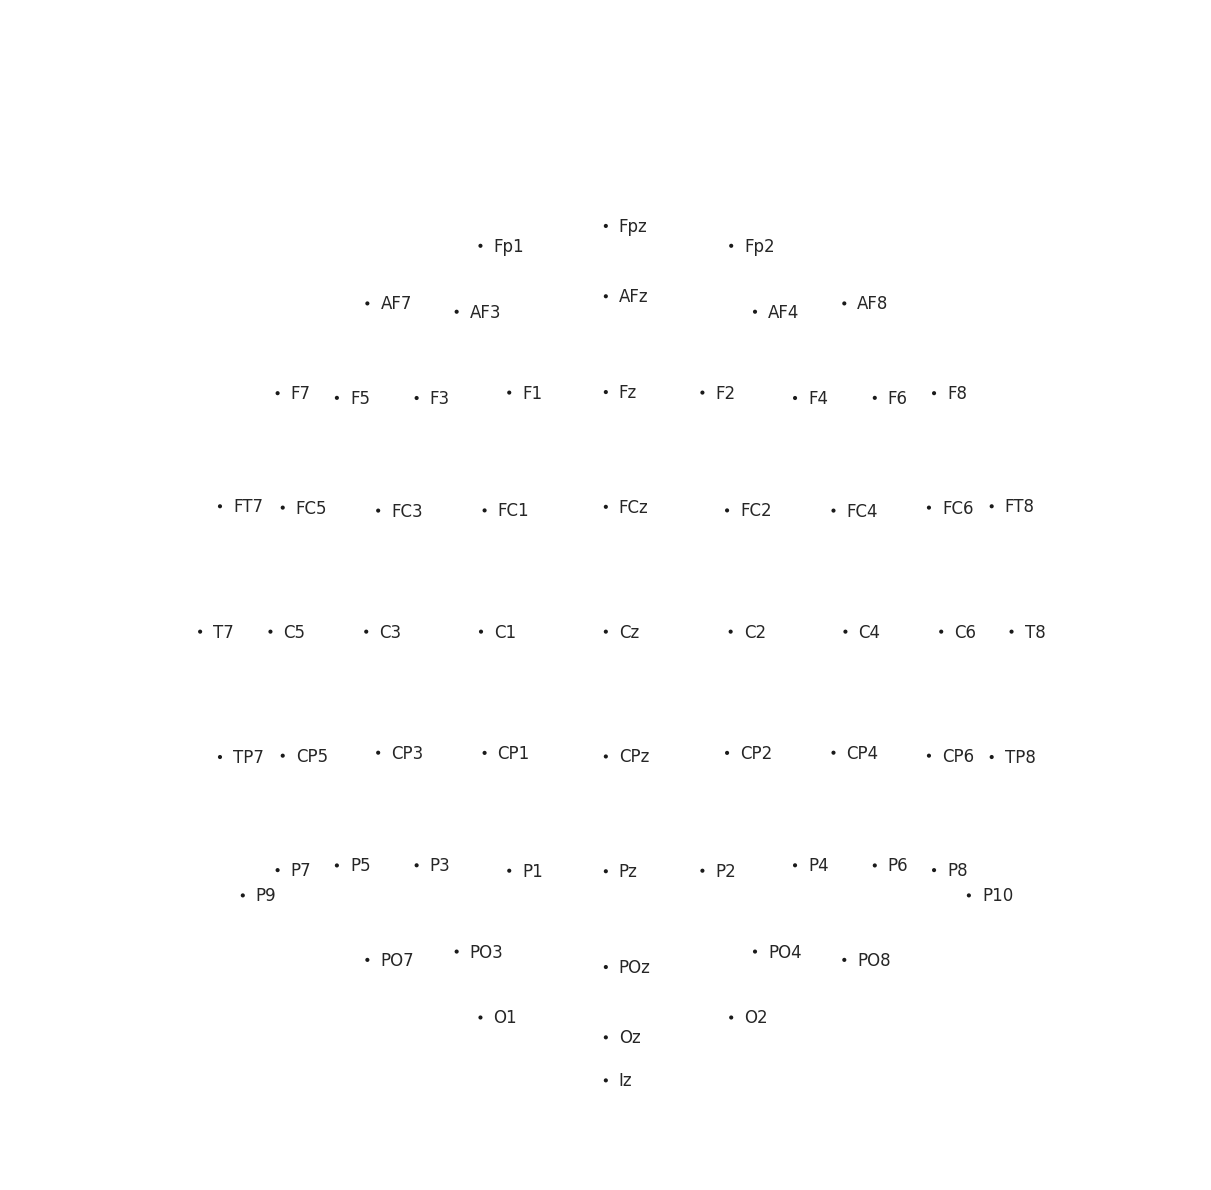

In [9]:
biosemi_montage = mne.channels.make_standard_montage('biosemi64')
biosemi_montage.plot()
plt.show()


In [10]:
# montage = mne.channels.make_standard_montage('standard_1005')
# raw.set_montage(montage)
# raw.plot_sensors(show_names=True);


In [11]:
eegbci.standardize(raw)  # set channel names
montage = make_standard_montage('standard_1005')
raw.set_montage(montage)


<RawEDF | S001R05.edf, 64 x 179040 (1119.0 s), ~87.5 MiB, data loaded>

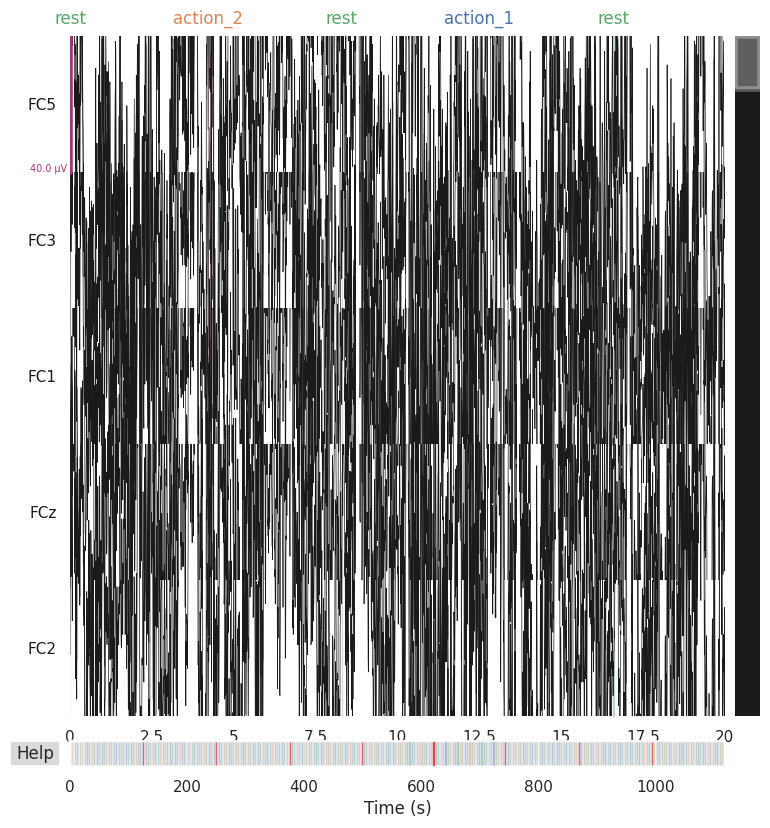

In [12]:
raw.plot(n_channels=5, duration = 20)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


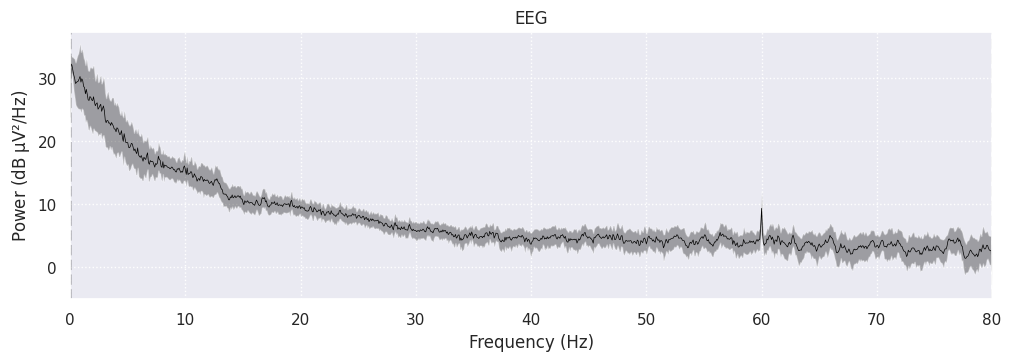

In [13]:
raw.plot_psd(average=True)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


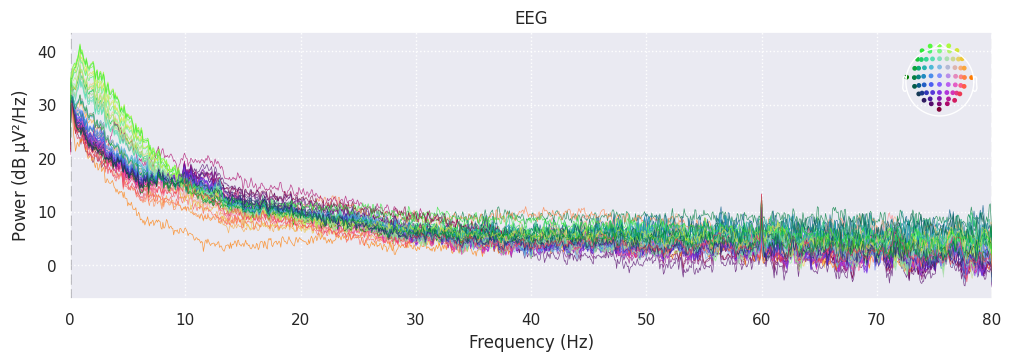

In [14]:
raw.plot_psd(average=False)
plt.show()


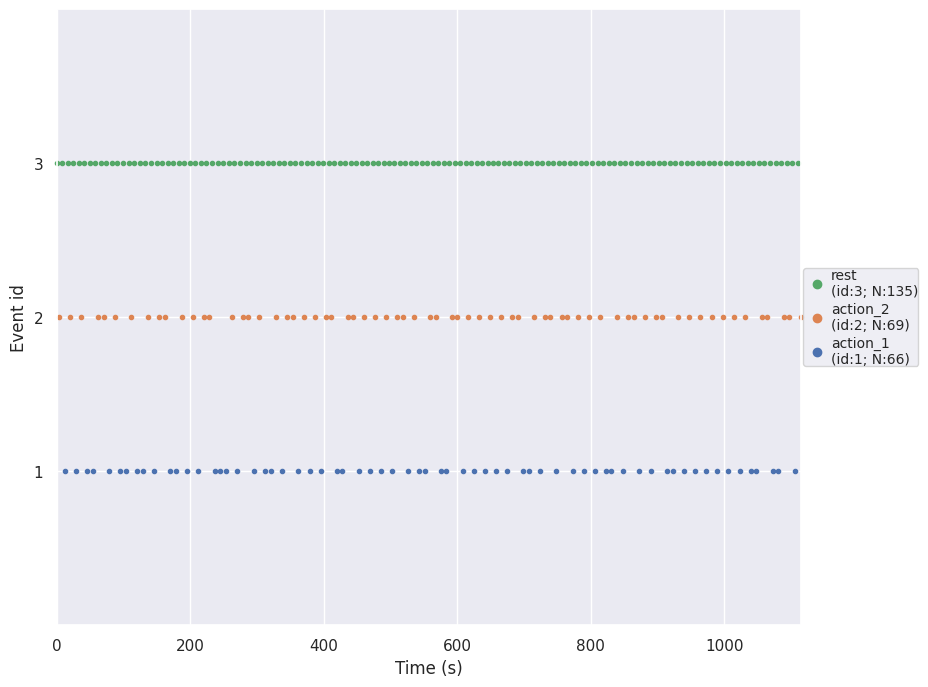

/tmp/ipykernel_2393651/1057779240.py:5: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.7)  # make room for legend


In [15]:
fig = mne.viz.plot_events(events, 
                        sfreq=raw.info['sfreq'],
                        first_samp=raw.first_samp, 
                        event_id=event_dict)
fig.subplots_adjust(right=0.7)  # make room for legend


In [16]:
raw.filter(8., 40., fir_design='firwin', skip_by_annotation='edge')


<RawEDF | S001R05.edf, 64 x 179040 (1119.0 s), ~87.5 MiB, data loaded>

/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


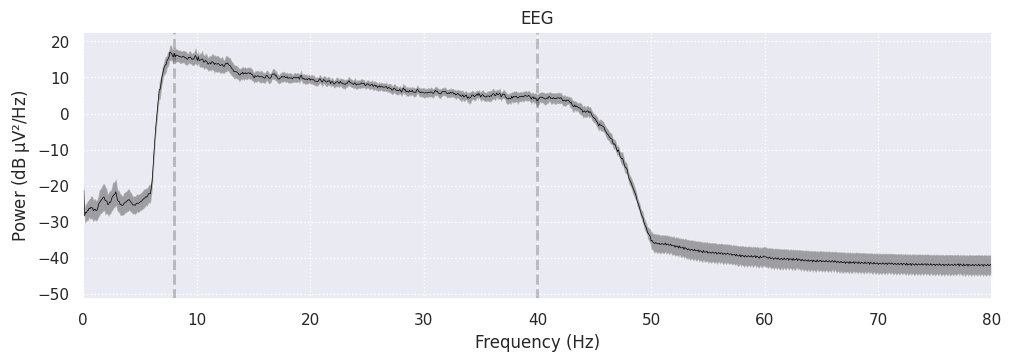

In [17]:
raw.plot_psd(average=True)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


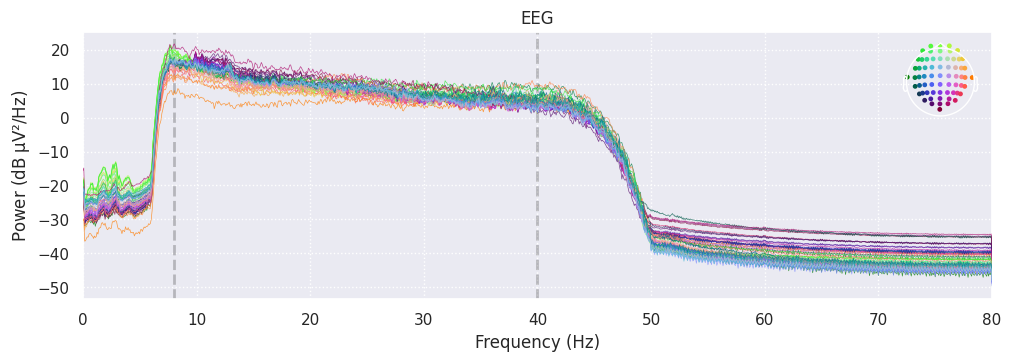

In [18]:
raw.plot_psd(average=False)
plt.show()


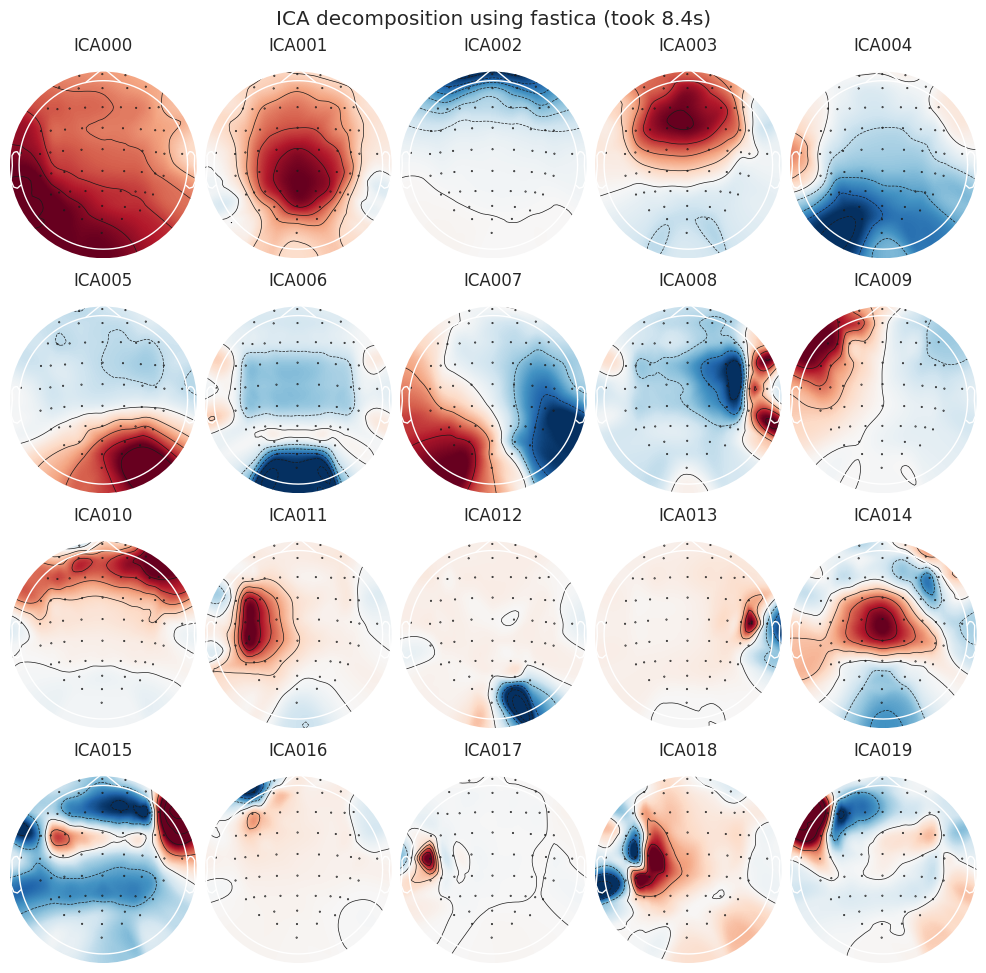

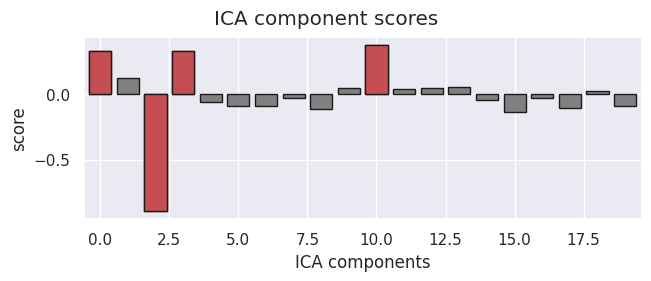

[2, 10, 0, 3] {'eog/0/Fpz': [0, 2, 3, 10], 'eog': [2, 10, 0, 3]}


In [19]:
def run_ica(raw, method, fit_params=None):
    raw_corrected = raw.copy()
    n_components=20
    
    ica = ICA(n_components=n_components, method=method, fit_params=fit_params, random_state=97)
    t0 = time()
    ica.fit(raw_corrected, picks=picks)
    fit_time = time() - t0
    title = ('ICA decomposition using %s (took %.1fs)' % (method, fit_time))
    ica.plot_components(title=title)
    plt.show()
    
    eog_indices, scores = ica.find_bads_eog(raw, ch_name='Fpz',threshold=1.5)
    ica.plot_scores(scores, exclude=eog_indices)  # look at r scores of components
    ica.exclude.extend(eog_indices) 
    raw_corrected = ica.apply(raw_corrected, n_pca_components = n_components, exclude = ica.exclude)
    print(ica.exclude, ica.labels_)
    return raw_corrected

raw_fastica = run_ica(raw, 'fastica')


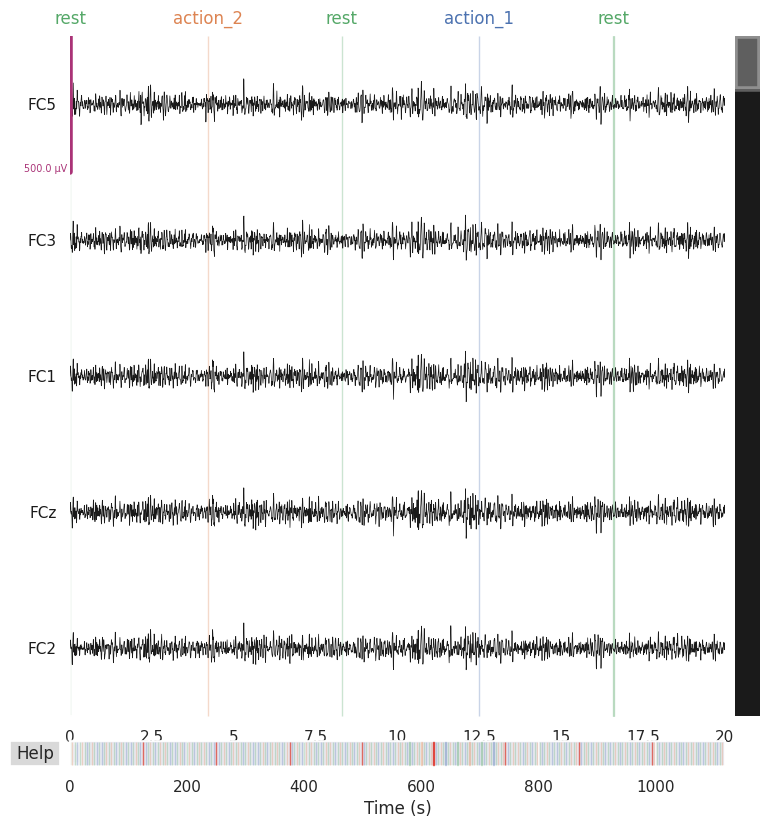

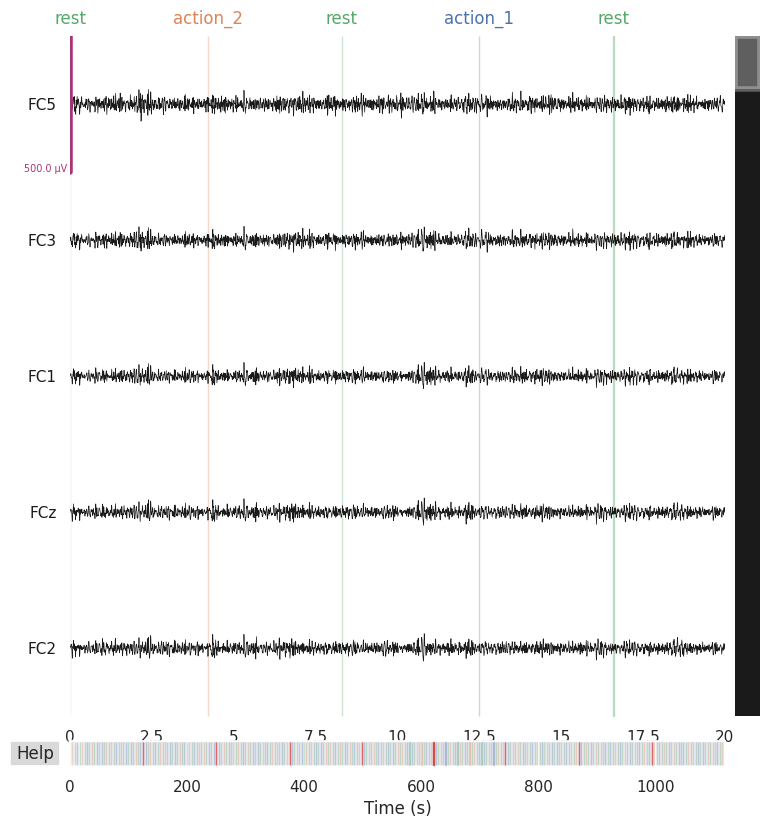

In [20]:
raw.plot(n_channels=5, start=0, duration=20,scalings=dict(eeg=250e-6))
raw_fastica.plot(n_channels=5, start=0, duration=20,scalings=dict(eeg=250e-6))
plt.show()


In [21]:
# event_id = {'do/feet': 1, 'do/hands': 2, 'imagine/feet': 3, 'imagine/hands': 4}
event_id = {'action_1': 1, 'action_2': 2}


In [22]:
tmin, tmax = -1., 4.

events, event_dict = mne.events_from_annotations(raw, event_id=event_id)
# events, event_dict = mne.events_from_annotations(raw_fastica, event_id=event_id)
print (event_dict)


{'action_1': 1, 'action_2': 2}


In [23]:
picks


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63])

In [24]:
epochs = Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks, baseline=None, preload=True)
# epochs = Epochs(raw_fastica, events, event_id, tmin, tmax, proj=True, picks=picks, baseline=None, preload=True)
epochs


<Epochs | 135 events (all good), -1 – 4 s (baseline off), ~52.9 MiB, data loaded,
 'action_1': 66
 'action_2': 69>

In [25]:
labels = epochs.events[:, -1] - 1
labels


array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1])

In [26]:
# evoked = epochs['imagine/feet'].average()
# evoked.plot_joint(title='Average Reference', show=False)
# plt.show()


In [27]:
# evoked = epochs['imagine/hands'].average()
# evoked.plot_joint(title='Average Reference', show=False)
# plt.show()


In [28]:
# %matplotlib qt 
# times = np.arange(-1, 4, 0.1)
# fig, anim = evoked.animate_topomap(times=times, ch_type='eeg', frame_rate=2, time_unit='s', blit=False)


In [29]:
# %matplotlib inline
# sns.set(rc={'figure.figsize':(12,8)})


# PIPELINE

In [30]:
# score_pipeline = -1
# models_pipeline = None


Shape of epochs_data: (135, 64, 801)
No existing score_pipeline found, will create a new one.
Testing CSP + LDA...
CSP + LDA - Accuracy: 0.6148 (± 0.1525)
  Individual fold scores: [0.48148148 0.62962963 0.7037037  0.66666667 0.59259259]
Testing CSP + LogReg...
CSP + LogReg - Accuracy: 0.6148 (± 0.0889)
  Individual fold scores: [0.55555556 0.59259259 0.66666667 0.66666667 0.59259259]
Testing CSP + RF...
CSP + RF - Accuracy: 0.7704 (± 0.0864)
  Individual fold scores: [0.85185185 0.77777778 0.74074074 0.74074074 0.74074074]
Testing CSP + MLP...
CSP + MLP - Accuracy: 0.5333 (± 0.1790)
  Individual fold scores: [0.48148148 0.51851852 0.59259259 0.40740741 0.66666667]
Testing PCA + LDA...
PCA + LDA - Accuracy: 0.4519 (± 0.1715)
  Individual fold scores: [0.33333333 0.59259259 0.48148148 0.40740741 0.44444444]
Testing PCA + LogReg...
PCA + LogReg - Accuracy: 0.4963 (± 0.0889)
  Individual fold scores: [0.51851852 0.51851852 0.40740741 0.51851852 0.51851852]
Testing PCA + RF...
PCA + RF - A

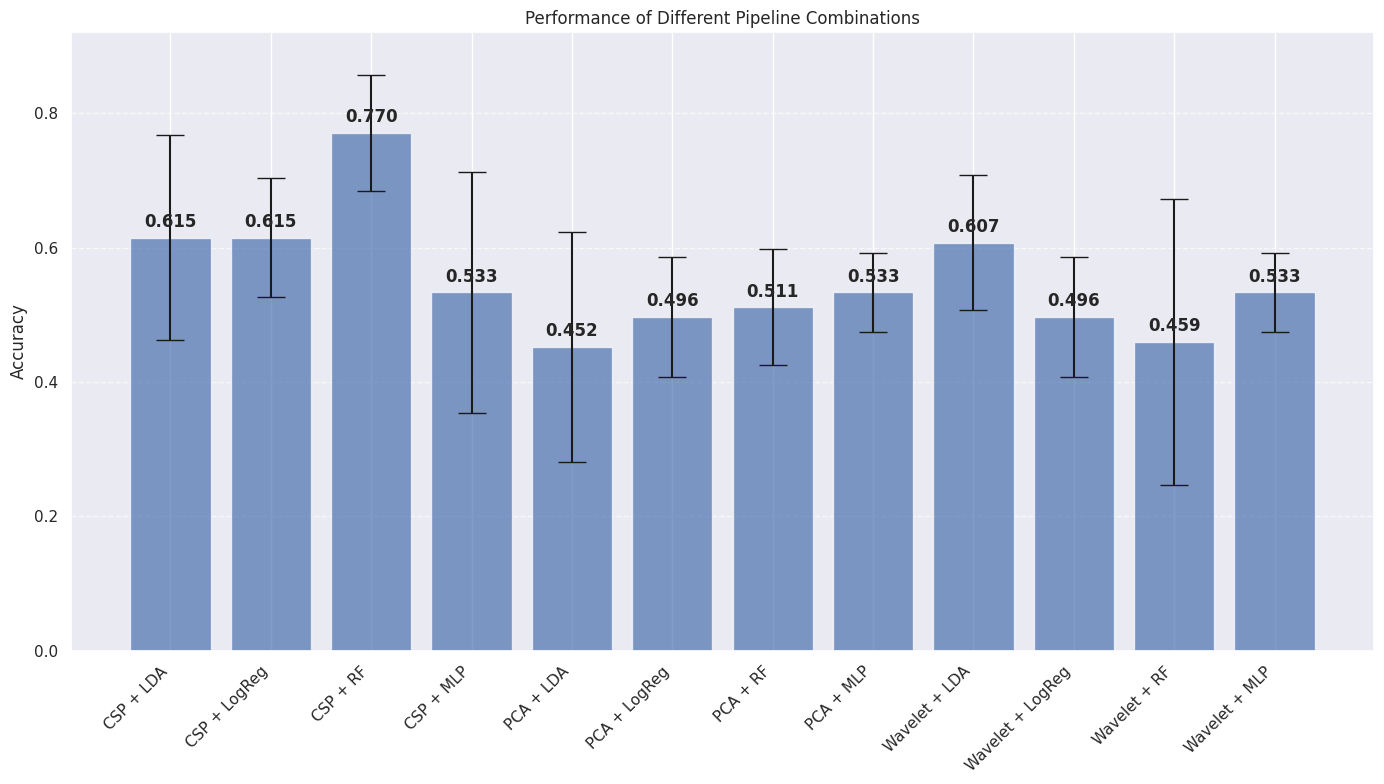

/tmp/ipykernel_2393651/4070733513.py:218: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels_to_plot)


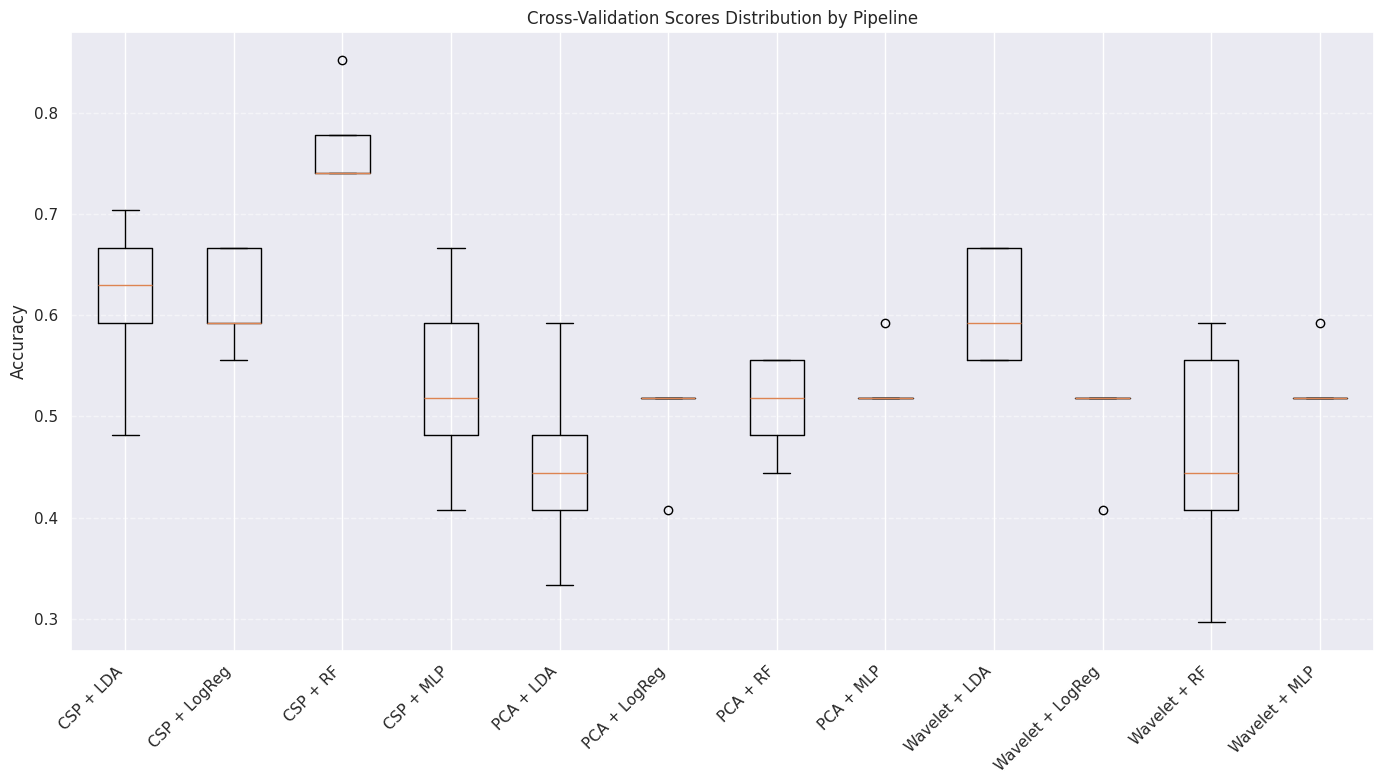

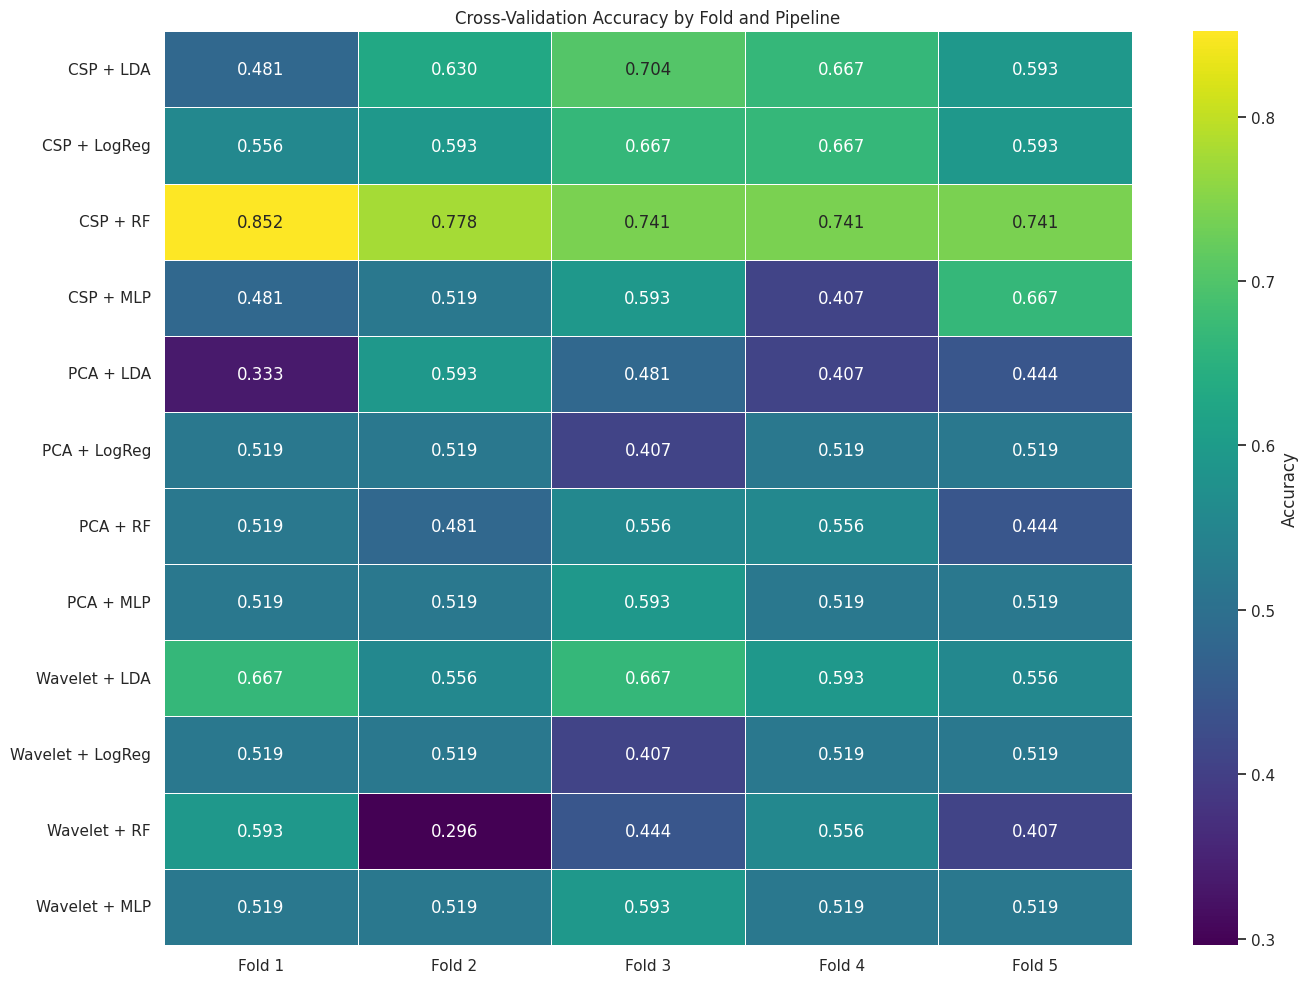

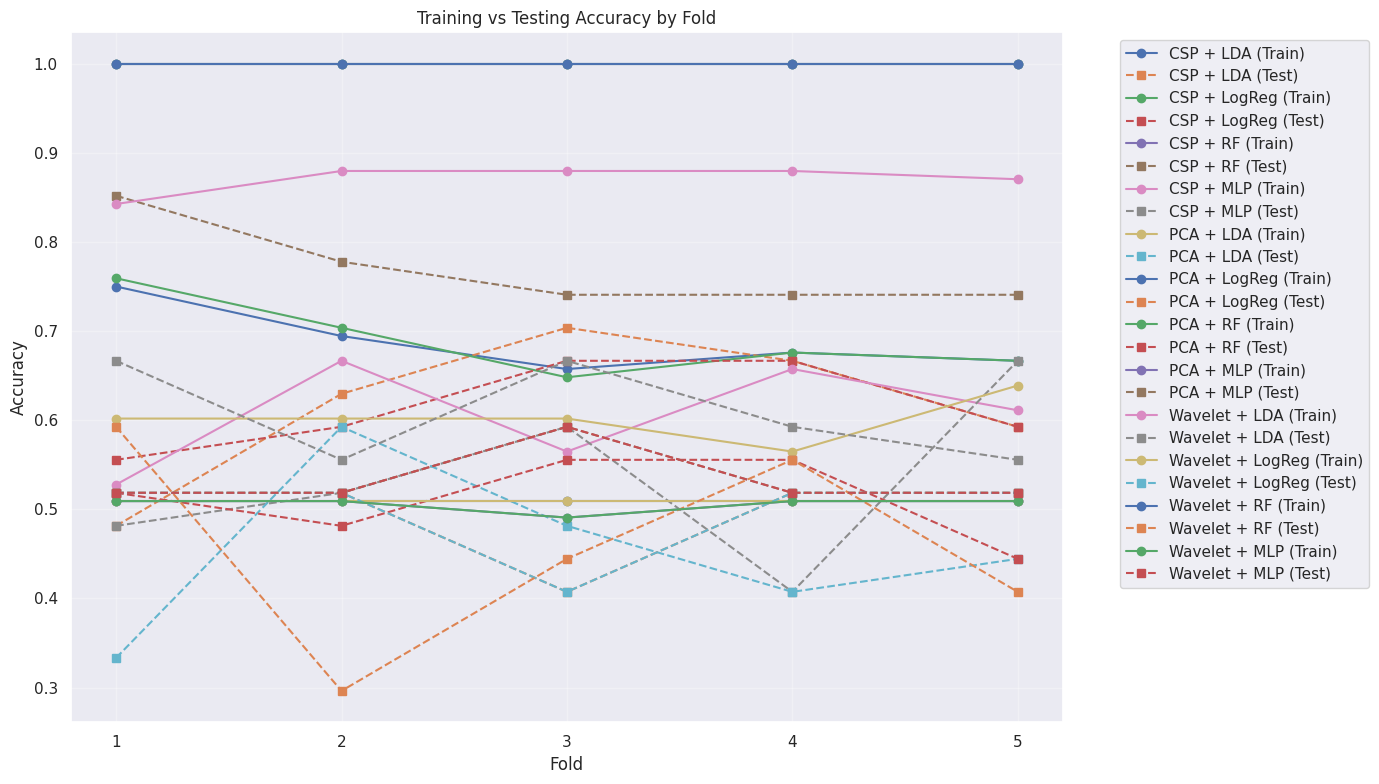


Best combination:
CSP + RF - Accuracy: 0.7704 (± 0.0864)
Individual fold scores: [0.85185185 0.77777778 0.74074074 0.74074074 0.74074074]
New best pipeline found! Accuracy: 0.7704


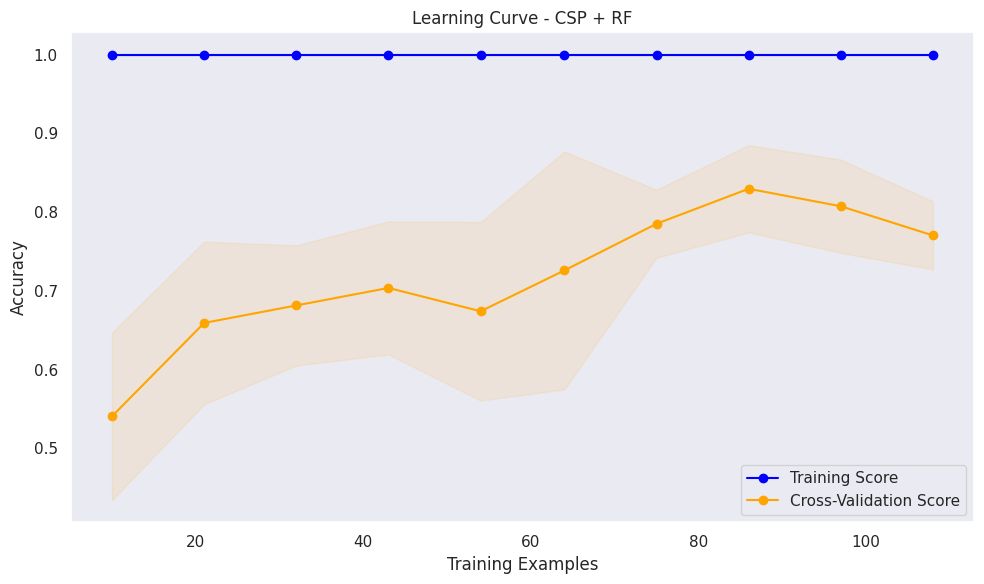

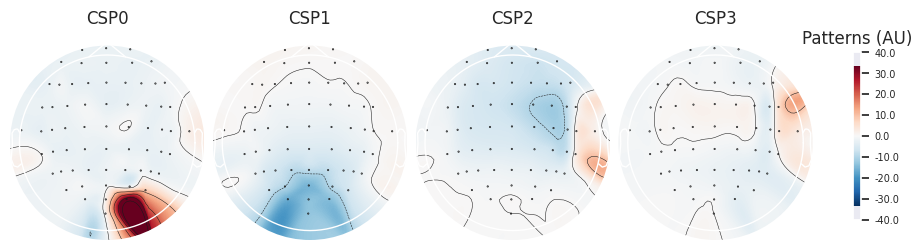


Mejor modelo guardado en: ../models/best_model.joblib
Información del modelo guardada en: ../models/best_model_info.joblib
Información del modelo guardada en JSON: ../models/best_model_info.json


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import ShuffleSplit, cross_val_score, cross_validate
from sklearn.decomposition import PCA
from mne.decoding import CSP
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import validation_curve
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Usar los epochs que ya tienes en tu entorno
# Asume que estás ejecutando este código después de tu bloque de código original
# que define 'epochs' y 'labels'
epochs_data = epochs.get_data().astype(np.float64)

# Verificar la forma de los datos
print(f"Shape of epochs_data: {epochs_data.shape}")
# Esperamos algo como (n_epochs, n_channels, n_timepoints)

# Transformador personalizado para remodelar datos 3D a 2D para PCA
class Reshaper(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.original_shape = None
        
    def fit(self, X, y=None):
        self.original_shape = X.shape
        return self
        
    def transform(self, X):
        # Remodelar de (n_epochs, n_channels, n_timepoints) a (n_epochs, n_channels*n_timepoints)
        n_epochs = X.shape[0]
        return X.reshape(n_epochs, -1)
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

# Transformador de wavelets para aplicar DWT a los datos EEG
class WaveletTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, wavelet='db4', level=5, feature_mode='mean_var'):
        self.wavelet = wavelet
        self.level = level
        self.feature_mode = feature_mode
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        import pywt
        
        n_epochs, n_channels, n_times = X.shape
        features = []
        
        for epoch_idx in range(n_epochs):
            epoch_features = []
            
            for ch_idx in range(n_channels):
                # Aplicar DWT
                coeffs = pywt.wavedec(X[epoch_idx, ch_idx], self.wavelet, level=self.level)
                
                # Extraer características según el modo seleccionado
                if self.feature_mode == 'concat':
                    # Concatenar todos los coeficientes (puede resultar en dimensiones muy altas)
                    ch_features = np.concatenate([coef.flatten() for coef in coeffs])
                elif self.feature_mode == 'mean_var':
                    # Calcular media y varianza por nivel (características más compactas)
                    ch_features = []
                    for coef in coeffs:
                        ch_features.extend([np.mean(coef), np.var(coef)])
                elif self.feature_mode == 'energy':
                    # Calcular energía por banda
                    ch_features = [np.sum(np.square(c)) for c in coeffs]
                
                epoch_features.extend(ch_features)
            
            features.append(epoch_features)
        
        return np.array(features)
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

# Definir los extractores de características a probar
feature_extractors = {
    'CSP': CSP(n_components=4, reg=None, log=True, norm_trace=False, cov_est='concat'),
    'PCA': make_pipeline(Reshaper(), PCA(n_components=10)),  # Usar reshaper antes de PCA
    'Wavelet': WaveletTransformer(wavelet='db4', level=4, feature_mode='mean_var')  # Añadir extractor basado en wavelets
}

# Definir los clasificadores a probar
classifiers = {
    'LDA': LinearDiscriminantAnalysis(solver='svd'),
    'LogReg': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'RF': RandomForestClassifier(n_estimators=100, random_state=42),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(100,), 
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size='auto',
        learning_rate='adaptive',
        max_iter=1000,
        random_state=42,
        validation_fraction=0.2,  
        early_stopping=True,  
        n_iter_no_change=10  # Detener si no hay mejora en 10 iteraciones
    )
}

# Definir la estrategia de validación cruzada
cv = ShuffleSplit(5, test_size=0.2, random_state=42)

# Almacenar resultados
results = {}
cv_results_detailed = {}
best_score = 0
best_pipeline = None

# Intentar obtener el mejor desempeño actual si existe
score_pipeline_current = -1
try:
    score_pipeline_current = score_pipeline
except NameError:
    print("No existing score_pipeline found, will create a new one.")

# Probar todas las combinaciones
for feat_name, feat_transformer in feature_extractors.items():
    for clf_name, classifier in classifiers.items():
        combo_name = f"{feat_name} + {clf_name}"
        print(f"Testing {combo_name}...")
        
        # Crear pipeline
        pipeline = make_pipeline(feat_transformer, classifier)
        
        try:
            # Usar cross_validate en lugar de cross_val_score para obtener más métricas
            cv_results = cross_validate(
                pipeline, 
                epochs_data, 
                labels, 
                cv=cv, 
                n_jobs=1,
                return_train_score=True,
                scoring='accuracy'
            )
            
            # Almacenar resultados detallados
            cv_results_detailed[combo_name] = cv_results
            
            # Calcular estadísticas
            test_scores = cv_results['test_score']
            
            # Almacenar resultados
            results[combo_name] = {
                'mean': test_scores.mean(), 
                'std': test_scores.std(),
                'pipeline': pipeline,
                'fold_scores': test_scores
            }
            
            # Verificar si este es el mejor pipeline hasta ahora
            if test_scores.mean() > best_score:
                best_score = test_scores.mean()
                best_pipeline = pipeline
            
            # Imprimir resultados para esta combinación
            print(f"{combo_name} - Accuracy: {test_scores.mean():.4f} (± {test_scores.std() * 2:.4f})")
            print(f"  Individual fold scores: {test_scores}")
            
        except Exception as e:
            print(f"Error with {combo_name}: {str(e)}")
            continue

# Visualizaciones solo si tenemos resultados
if results:
    # 1. Gráfico de barras tradicional (como en el original, pero mejorado)
    plt.figure(figsize=(14, 8))
    combinations = list(results.keys())
    means = [results[combo]['mean'] for combo in combinations]
    stds = [results[combo]['std'] * 2 for combo in combinations]

    bars = plt.bar(combinations, means, yerr=stds, capsize=10, alpha=0.7)
    
    # Añadir etiquetas de valor sobre las barras
    for bar, value in zip(bars, means):
        plt.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.01, 
                f'{value:.3f}', 
                ha='center', va='bottom',
                fontweight='bold')
    
    plt.ylabel('Accuracy')
    plt.title('Performance of Different Pipeline Combinations')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, min(1.0, max(means) + 0.15))  # Ajustar el límite superior
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 2. Visualización de CV detallado - Boxplot
    plt.figure(figsize=(14, 8))
    data_to_plot = []
    labels_to_plot = []
    
    for combo_name, result in results.items():
        data_to_plot.append(result['fold_scores'])
        labels_to_plot.append(combo_name)
    
    plt.boxplot(data_to_plot, labels=labels_to_plot)
    plt.title('Cross-Validation Scores Distribution by Pipeline')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # 3. Heatmap de las puntuaciones por fold
    plt.figure(figsize=(14, 10))
    
    # Preparar datos para el heatmap
    heatmap_data = np.zeros((len(combinations), 5))  # 5 folds
    for i, combo in enumerate(combinations):
        heatmap_data[i] = results[combo]['fold_scores']
    
    # Crear DataFrame para seaborn
    df_heatmap = pd.DataFrame(
        heatmap_data, 
        index=combinations,
        columns=[f'Fold {i+1}' for i in range(5)]
    )
    
    # Dibujar heatmap
    sns.heatmap(df_heatmap, annot=True, cmap='viridis', fmt='.3f',
                linewidths=.5, cbar_kws={'label': 'Accuracy'})
    plt.title('Cross-Validation Accuracy by Fold and Pipeline')
    plt.tight_layout()
    plt.show()
    
    # 4. Visualización avanzada: Desempeño de entrenamiento vs prueba
    plt.figure(figsize=(14, 8))
    
    for combo_name, cv_result in cv_results_detailed.items():
        plt.plot(range(1, 6), cv_result['train_score'], 'o-', label=f'{combo_name} (Train)')
        plt.plot(range(1, 6), cv_result['test_score'], 's--', label=f'{combo_name} (Test)')
    
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.title('Training vs Testing Accuracy by Fold')
    plt.xticks(range(1, 6))
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Imprimir el mejor modelo
    best_combo = max(results.items(), key=lambda x: x[1]['mean'])
    print("\nBest combination:")
    print(f"{best_combo[0]} - Accuracy: {best_combo[1]['mean']:.4f} (± {best_combo[1]['std'] * 2:.4f})")
    print(f"Individual fold scores: {best_combo[1]['fold_scores']}")

    # Actualizar score_pipeline y models_pipeline si el nuevo mejor score es mejor
    try:
        if best_score > score_pipeline_current:
            print(f"New best pipeline found! Accuracy: {best_score:.4f}")
            score_pipeline = best_score
            models_pipeline = best_pipeline
        else:
            print(f"No improvement over current best pipeline ({score_pipeline_current:.4f})")
    except NameError:
        print("Creating new score_pipeline with value:", best_score)
        score_pipeline = best_score
        models_pipeline = best_pipeline

    # 5. Visualizar la curva de aprendizaje para el mejor modelo
    if best_pipeline is not None:
        # Calcular curva de aprendizaje para el mejor pipeline
        train_sizes = np.linspace(0.1, 1.0, 10)
        try:
            train_sizes, train_scores, test_scores = learning_curve(
                best_pipeline, epochs_data, labels, 
                train_sizes=train_sizes, cv=cv, 
                scoring='accuracy', n_jobs=1
            )
            
            # Calcular medias y desviaciones estándar
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            test_mean = np.mean(test_scores, axis=1)
            test_std = np.std(test_scores, axis=1)
            
            # Graficar curva de aprendizaje
            plt.figure(figsize=(10, 6))
            plt.title(f'Learning Curve - {best_combo[0]}')
            plt.xlabel('Training Examples')
            plt.ylabel('Accuracy')
            plt.grid()
            
            plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
            plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
            plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
            plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-Validation Score')
            
            plt.legend(loc='best')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error creating learning curve: {str(e)}")

    # Si el mejor modelo utiliza CSP, visualizar los patrones (como en el código original)
    if 'CSP' in best_combo[0]:
        try:
            # Obtener el paso CSP del pipeline
            if hasattr(best_pipeline, 'named_steps') and 'csp' in best_pipeline.named_steps:
                csp = best_pipeline.named_steps['csp']
                # Ajustar CSP a los datos completos
                csp.fit_transform(epochs_data, labels)
                # Graficar patrones
                csp.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)
                plt.show()
            else:
                # Intentar encontrar el componente CSP por tipo
                for step_name, step in best_pipeline.named_steps.items():
                    if isinstance(step, CSP):
                        step.fit_transform(epochs_data, labels)
                        step.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)
                        plt.show()
                        break
                else:
                    print("Could not find CSP step in pipeline to visualize patterns")
        except Exception as e:
            print(f"Error visualizing CSP patterns: {str(e)}")
    
    # 6. Early Stopping: Analizar la convergencia/sobreajuste para el mejor modelo MLP (si aplica)
    if 'MLP' in best_combo[0]:
        try:
            # Para visualizar el impacto del early stopping, hacemos una búsqueda de hiperparámetros
            # con diferentes parámetros de early stopping
            mlp_params = {
                'mlpclassifier__max_iter': [200, 500, 1000],
                'mlpclassifier__early_stopping': [True, False],
                'mlpclassifier__n_iter_no_change': [5, 10, 20]
            }
            
            # Crear una copia del mejor pipeline para no modificar el original
            best_pipeline_copy = best_pipeline
            
            # Realizar GridSearchCV
            grid = GridSearchCV(best_pipeline_copy, mlp_params, cv=cv, n_jobs=1, scoring='accuracy')
            grid.fit(epochs_data, labels)
            
            # Mostrar los mejores parámetros
            print("\nBest early stopping parameters for MLP:")
            print(grid.best_params_)
            print(f"Best CV score with these parameters: {grid.best_score_:.4f}")
            
            # Visualizar resultados de GridSearchCV para early stopping
            plt.figure(figsize=(10, 6))
            
            # Extraer y organizar resultados
            results_df = pd.DataFrame(grid.cv_results_)
            
            # Filtrar para parametros específicos de early stopping
            early_stop_true = results_df[results_df['param_mlpclassifier__early_stopping'] == True]
            early_stop_false = results_df[results_df['param_mlpclassifier__early_stopping'] == False]
            
            # Graficar
            plt.plot(early_stop_true['param_mlpclassifier__max_iter'], 
                    early_stop_true['mean_test_score'], 'o-', label='With Early Stopping')
            plt.plot(early_stop_false['param_mlpclassifier__max_iter'], 
                    early_stop_false['mean_test_score'], 's--', label='Without Early Stopping')
            
            plt.xlabel('Max Iterations')
            plt.ylabel('CV Accuracy Score')
            plt.title('Impact of Early Stopping on MLP Performance')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Error analyzing early stopping: {str(e)}")

    # Análisis adicional para el transformador de Wavelets (si se utilizó en el mejor pipeline)
    if 'Wavelet' in best_combo[0]:
        try:
            # Probar diferentes configuraciones de wavelets
            wavelet_types = ['db4', 'sym5', 'coif3', 'haar']
            wavelet_levels = [2, 3, 4, 5]
            
            # Preparar resultados
            wavelet_results = {}
            
            for wtype in wavelet_types:
                for level in wavelet_levels:
                    wavelet_name = f"Wavelet ({wtype}, L{level})"
                    print(f"Testing {wavelet_name}...")
                    
                    # Crear pipeline con esta configuración de wavelet
                    wavelet_transformer = WaveletTransformer(wavelet=wtype, level=level, feature_mode='mean_var')
                    classifier = best_pipeline.named_steps[list(best_pipeline.named_steps.keys())[-1]]
                    pipeline = make_pipeline(wavelet_transformer, classifier)
                    
                    try:
                        # Calcular puntuación
                        scores = cross_val_score(pipeline, epochs_data, labels, cv=cv, n_jobs=1)
                        
                        # Almacenar resultado
                        wavelet_results[wavelet_name] = {
                            'mean': scores.mean(),
                            'std': scores.std(),
                            'scores': scores
                        }
                        
                        print(f"{wavelet_name} - Accuracy: {scores.mean():.4f} (± {scores.std() * 2:.4f})")
                        
                    except Exception as e:
                        print(f"Error with {wavelet_name}: {str(e)}")
                        continue
            
            # Visualizar resultados de las distintas configuraciones de wavelets
            if wavelet_results:
                plt.figure(figsize=(14, 8))
                
                # Organizar datos para visualización
                wavelet_names = list(wavelet_results.keys())
                wavelet_means = [wavelet_results[name]['mean'] for name in wavelet_names]
                wavelet_stds = [wavelet_results[name]['std'] * 2 for name in wavelet_names]
                
                # Crear gráfico de barras
                bars = plt.bar(wavelet_names, wavelet_means, yerr=wavelet_stds, capsize=10, alpha=0.7)
                
                # Añadir etiquetas de valor
                for bar, value in zip(bars, wavelet_means):
                    plt.text(bar.get_x() + bar.get_width()/2, 
                            bar.get_height() + 0.01, 
                            f'{value:.3f}', 
                            ha='center', va='bottom',
                            fontweight='bold')
                
                plt.ylabel('Accuracy')
                plt.title('Performance of Different Wavelet Configurations')
                plt.xticks(rotation=45, ha='right')
                plt.grid(axis='y', linestyle='--', alpha=0.7)
                plt.tight_layout()
                plt.show()
        
        except Exception as e:
            print(f"Error analyzing wavelet configurations: {str(e)}")
else:
    print("No successful pipeline combinations to report.")


# Código para guardar el mejor modelo
import os
import joblib
from datetime import datetime

# Crear el directorio models si no existe
os.makedirs('../models', exist_ok=True)

# Generar nombre de archivo con fecha y hora
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
best_combo_name = max(results.items(), key=lambda x: x[1]['mean'])[0]
filename = f"../models/best_model.joblib"

# Guardar el mejor pipeline
joblib.dump(best_pipeline, filename)
print(f"\nMejor modelo guardado en: {filename}")

# Guardar información adicional sobre el modelo
model_info = {
    'pipeline_name': best_combo_name,
    'accuracy': best_score,
    'timestamp': timestamp,
    'fold_scores': results[best_combo_name]['fold_scores'].tolist(),
    'std_deviation': results[best_combo_name]['std'],
    'all_tested_pipelines': list(results.keys()),
    'feature_extractor': best_combo_name.split(' + ')[0],
    'classifier': best_combo_name.split(' + ')[1],
    'model_file': filename
}

# Guardar info en formato joblib
info_filename = f"../models/best_model_info.joblib"
joblib.dump(model_info, info_filename)
print(f"Información del modelo guardada en: {info_filename}")

# Guardar info en formato JSON
import json
json_filename = f"../models/best_model_info.json"
with open(json_filename, 'w') as json_file:
    # Convertir arrays numpy a listas para serialización JSON
    json.dump(model_info, json_file, indent=4)
print(f"Información del modelo guardada en JSON: {json_filename}")


In [32]:
score_pipeline


0.7703703703703703

In [33]:
models_pipeline


Pipeline(steps=[('csp', CSP(log=True)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [34]:
# import joblib
# import os
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns
# from datetime import datetime

# # Ruta específica al modelo que falló
# model_path = "../models/best_model.joblib"

# try:
#     # Cargar el modelo
#     loaded_pipeline = joblib.load(model_path)
#     print(f"Modelo cargado desde: {model_path}")
    
#     # Dividir los datos
#     x_train, x_test, y_train, y_test = train_test_split(epochs_data, labels, test_size=0.2, shuffle=True, random_state=42)
    
#     # PASO CLAVE: Entrenar el modelo cargado con los datos de entrenamiento
#     print("Entrenando el modelo...")
#     loaded_pipeline.fit(x_train, y_train)
#     print("Modelo entrenado correctamente.")
    
#     # Evaluar en el conjunto de prueba
#     print("Evaluando en el conjunto de prueba...")
#     y_pred = loaded_pipeline.predict(x_test)
    
#     # Calcular métricas
#     accuracy = accuracy_score(y_test, y_pred)
#     print(f"\nExactitud en conjunto de prueba: {accuracy:.4f}")
    
#     # Mostrar reporte de clasificación
#     print("\nReporte de clasificación:")
#     print(classification_report(y_test, y_pred))
    
#     # Visualizar matriz de confusión
#     plt.figure(figsize=(8, 6))
#     cm = confusion_matrix(y_test, y_pred)
    
#     # Si tenemos muchas clases, normalizamos la matriz
#     if len(np.unique(labels)) > 2:
#         cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
#         sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues')
#         plt.title('Matriz de Confusión Normalizada')
#     else:
#         sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
#         plt.title('Matriz de Confusión')
    
#     plt.xlabel('Predicción')
#     plt.ylabel('Valor Real')
#     plt.show()
    
#     # Guardar el modelo ahora correctamente entrenado
#     os.makedirs('./models', exist_ok=True)  # Asegurarse de que el directorio existe
#     retrain_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
#     retrain_filename = f"../models/fixed_model_CSP_RF_{retrain_timestamp}.joblib"
    
#     joblib.dump(loaded_pipeline, retrain_filename)
#     print(f"\nModelo entrenado guardado en: {retrain_filename}")
    
#     # Guardar información del modelo
#     retrain_info = {
#         'original_model': model_path,
#         'fixed_timestamp': retrain_timestamp,
#         'test_accuracy': float(accuracy),
#         'training_samples': len(x_train),
#         'test_samples': len(x_test)
#     }
    
#     # Guardar en JSON
#     import json
#     retrain_json = f"../models/fixed_model_info_{retrain_timestamp}.json"
#     with open(retrain_json, 'w') as f:
#         json.dump(retrain_info, f, indent=4)
    
#     print(f"Información del modelo guardada en: {retrain_json}")

# except Exception as e:
#     print(f"Error: {str(e)}")


In [35]:
# x_train, x_test, y_train, y_test = train_test_split(epochs_data, labels, test_size=0.2, shuffle=True)
# models_pipeline.fit(x_train, y_train)


In [36]:
# models_pipeline.predict(x_test)


Modelo cargado desde: ../models/best_model.joblib
El modelo necesita entrenamiento: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
Entrenando el modelo...
Modelo entrenado correctamente.
Valores reales (y_test):
[1 1 0 1 1 1 0 0 0 1 1 0 1 0 0 1 0 1 0 0 0 1 1 1 1 0 0]

Valores predichos (y_pred):
[1 1 0 1 1 1 0 0 1 1 0 0 1 0 1 1 0 1 0 0 0 1 1 1 1 1 0]

Precisión del modelo: 0.8519
Score del modelo: 0.8519

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.91      0.77      0.83        13
           1       0.81      0.93      0.87        14

    accuracy                           0.85        27
   macro avg       0.86      0.85      0.85        27
weighted avg       0.86      0.85      0.85        27



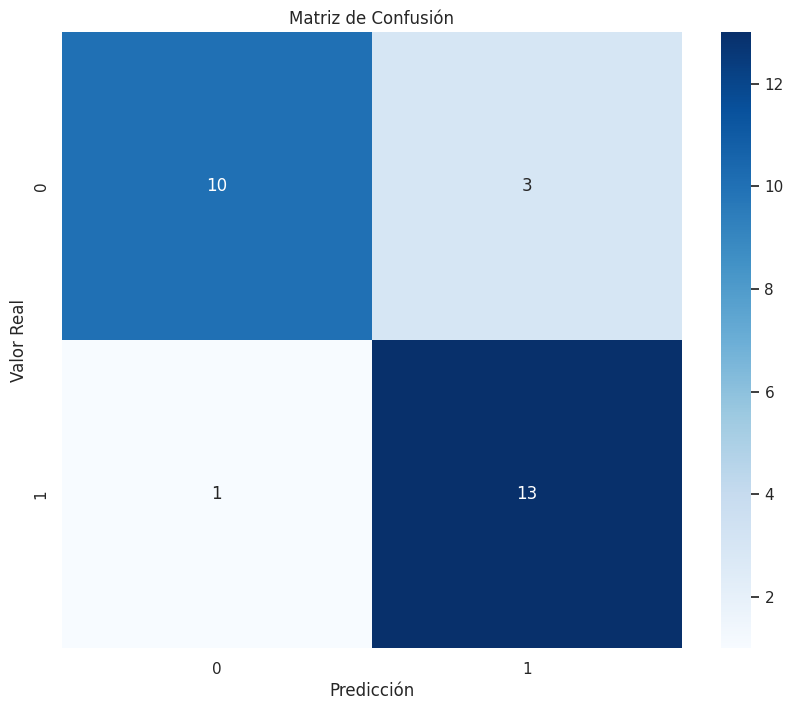


Índices donde hubo errores de predicción: [ 8 10 14 25]
Total de errores: 4 de 27 (14.81%)


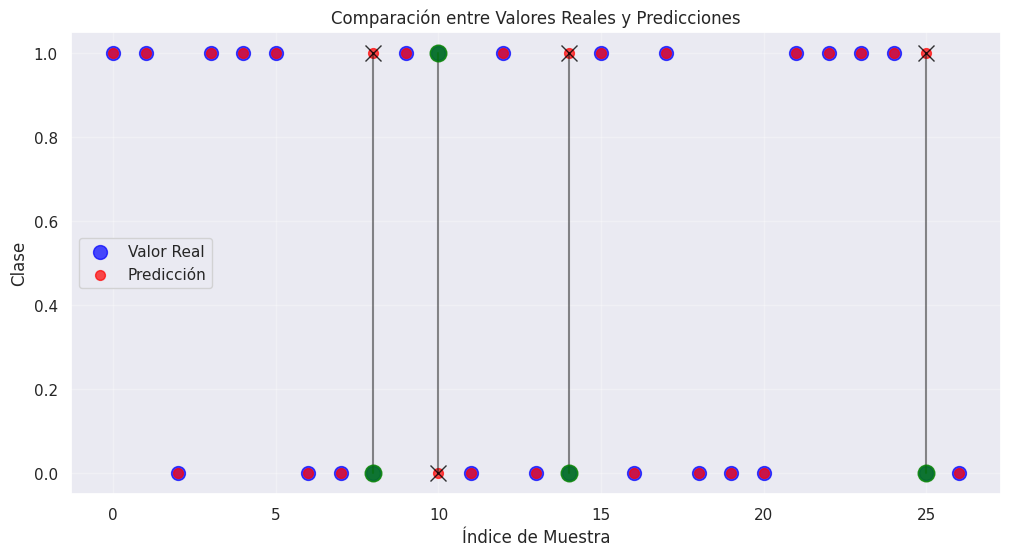


Tabla de comparación:
Índice | Valor Real | Predicción | ¿Correcto?
---------------------------------------------
     0 |          1 |          1 |     ✓     
     1 |          1 |          1 |     ✓     
     2 |          0 |          0 |     ✓     
     3 |          1 |          1 |     ✓     
     4 |          1 |          1 |     ✓     
     5 |          1 |          1 |     ✓     
     6 |          0 |          0 |     ✓     
     7 |          0 |          0 |     ✓     
     8 |          0 |          1 |     ✗     
     9 |          1 |          1 |     ✓     
    10 |          1 |          0 |     ✗     
    11 |          0 |          0 |     ✓     
    12 |          1 |          1 |     ✓     
    13 |          0 |          0 |     ✓     
    14 |          0 |          1 |     ✗     
    15 |          1 |          1 |     ✓     
    16 |          0 |          0 |     ✓     
    17 |          1 |          1 |     ✓     
    18 |          0 |          0 |     ✓     
    19 |   

In [43]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import os

# Primero cargar el modelo
model_path = "../models/best_model.joblib"

try:
    # Cargar el modelo
    loaded_pipeline = joblib.load(model_path)
    print(f"Modelo cargado desde: {model_path}")
    
    # Dividir los datos
    x_train, x_test, y_train, y_test = train_test_split(epochs_data, labels, test_size=0.2, shuffle=True, random_state=42)
    
    # Entrenar el modelo si es necesario (si no está entrenado)
    try:
        # Intentar hacer una predicción simple para comprobar si está entrenado
        loaded_pipeline.predict(x_test[:1])
        print("El modelo ya está entrenado, procediendo a la evaluación...")
    except Exception as e:
        print(f"El modelo necesita entrenamiento: {str(e)}")
        print("Entrenando el modelo...")
        loaded_pipeline.fit(x_train, y_train)
        print("Modelo entrenado correctamente.")
    
    # Obtener predicciones del modelo
    y_pred = loaded_pipeline.predict(x_test)
    
    # Imprimir valores reales y predicciones
    print("Valores reales (y_test):")
    print(y_test)
    print("\nValores predichos (y_pred):")
    print(y_pred)
    
    # Calcular y mostrar precisión del modelo
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nPrecisión del modelo: {accuracy:.4f}")
    print(f"Score del modelo: {loaded_pipeline.score(x_test, y_test):.4f}")
    
    # Crear informe de clasificación
    print("\nInforme de clasificación:")
    print(classification_report(y_test, y_pred))
    
    # Crear matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    class_names = np.unique(np.concatenate([y_test, y_pred]))
    
    # Visualizar matriz de confusión
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusión')
    plt.show()
    
    # Comparar predicciones vs valores reales (visualización)
    plt.figure(figsize=(12, 6))
    plt.scatter(range(len(y_test)), y_test, color='blue', label='Valor Real', alpha=0.7, s=100)
    plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicción', alpha=0.7, s=50)
    plt.xlabel('Índice de Muestra')
    plt.ylabel('Clase')
    plt.title('Comparación entre Valores Reales y Predicciones')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Mostrar errores en la predicción
    incorrect = np.where(y_test != y_pred)[0]
    if len(incorrect) > 0:
        print(f"\nÍndices donde hubo errores de predicción: {incorrect}")
        print(f"Total de errores: {len(incorrect)} de {len(y_test)} ({len(incorrect)/len(y_test)*100:.2f}%)")
        
        # Resaltar errores en el gráfico
        for idx in incorrect:
            plt.plot([idx, idx], [y_test[idx], y_pred[idx]], 'k-', alpha=0.5)
            plt.plot(idx, y_test[idx], 'o', color='green', alpha=0.8, markersize=12)
            plt.plot(idx, y_pred[idx], 'x', color='black', alpha=0.8, markersize=12)
    
    plt.show()
    
    # Tabla de comparación de valores reales y predicciones
    n_samples = len(y_test)
    comparison_table = np.column_stack((y_test[:n_samples], y_pred[:n_samples]))
    print("\nTabla de comparación:")
    print("Índice | Valor Real | Predicción | ¿Correcto?")
    print("-" * 45)
    for i in range(n_samples):
        is_correct = "✓" if y_test[i] == y_pred[i] else "✗"
        print(f"{i:6d} | {y_test[i]:10} | {y_pred[i]:10} | {is_correct:^10}")
    
    # Guardar el modelo ahora correctamente entrenado
    os.makedirs('./models', exist_ok=True)
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_path = f"../models/evaluated_model.joblib"
    
    joblib.dump(loaded_pipeline, save_path)
    print(f"\nModelo evaluado guardado en: {save_path}")
    
    # Guardar resultados de evaluación en JSON
    import json
    eval_results = {
        'accuracy': float(accuracy),
        'model_path': model_path,
        'timestamp': timestamp,
        'class_names': class_names.tolist(),
        'confusion_matrix': cm.tolist(),
        'n_test_samples': len(y_test),
        'n_errors': len(incorrect),
        'error_rate': float(len(incorrect)/len(y_test))
    }
    
    eval_json_path = f"../models/evaluation_results.json"
    with open(eval_json_path, 'w') as f:
        json.dump(eval_results, f, indent=4)
    
    print(f"Resultados de evaluación guardados en: {eval_json_path}")
    print(f"Accuracy: {accuracy}")

except Exception as e:
    print(f"Error en la evaluación: {str(e)}")


In [38]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# import seaborn as sns

# # Obtener predicciones del modelo
# y_pred = models_pipeline.predict(x_test)

# # Imprimir valores reales y predicciones
# print("Valores reales (y_test):")
# print(y_test)
# print("\nValores predichos (y_pred):")
# print(y_pred)

# # Calcular y mostrar precisión del modelo
# accuracy = accuracy_score(y_test, y_pred)
# print(f"\nPrecisión del modelo: {accuracy:.4f}")
# print(f"Score del modelo: {models_pipeline.score(x_test, y_test):.4f}")

# # Crear informe de clasificación
# print("\nInforme de clasificación:")
# print(classification_report(y_test, y_pred))

# # Crear matriz de confusión
# cm = confusion_matrix(y_test, y_pred)
# class_names = np.unique(np.concatenate([y_test, y_pred]))

# # Visualizar matriz de confusión
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=class_names, 
#             yticklabels=class_names)
# plt.xlabel('Predicción')
# plt.ylabel('Valor Real')
# plt.title('Matriz de Confusión')
# plt.show()

# # Comparar predicciones vs valores reales (visualización)
# plt.figure(figsize=(12, 6))
# plt.scatter(range(len(y_test)), y_test, color='blue', label='Valor Real', alpha=0.7, s=100)
# plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicción', alpha=0.7, s=50)
# plt.xlabel('Índice de Muestra')
# plt.ylabel('Clase')
# plt.title('Comparación entre Valores Reales y Predicciones')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Mostrar errores en la predicción
# incorrect = np.where(y_test != y_pred)[0]
# if len(incorrect) > 0:
#     print(f"\nÍndices donde hubo errores de predicción: {incorrect}")
#     print(f"Total de errores: {len(incorrect)} de {len(y_test)} ({len(incorrect)/len(y_test)*100:.2f}%)")
    
#     # Resaltar errores en el gráfico
#     for idx in incorrect:
#         plt.plot([idx, idx], [y_test[idx], y_pred[idx]], 'k-', alpha=0.5)
#         plt.plot(idx, y_test[idx], 'o', color='green', alpha=0.8, markersize=12)
#         plt.plot(idx, y_pred[idx], 'x', color='black', alpha=0.8, markersize=12)

# plt.show()

# # Tabla de comparación de valores reales y predicciones
# n_samples = len(y_test)
# comparison_table = np.column_stack((y_test[:n_samples], y_pred[:n_samples]))
# print("\nTabla de comparación:")
# print("Índice | Valor Real | Predicción | ¿Correcto?")
# print("-" * 45)
# for i in range(n_samples):
#     is_correct = "✓" if y_test[i] == y_pred[i] else "✗"
#     print(f"{i:6d} | {y_test[i]:10} | {y_pred[i]:10} | {is_correct:^10}")


In [39]:
# models_pipeline.score(x_test, y_test)


## EVALUATION

In [40]:




# picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude='bads')
# eegbci.standardize(raw)  # set channel names
# montage = make_standard_montage('standard_1005')
# raw.set_montage(montage)
# raw.filter(8., 40., fir_design='firwin', skip_by_annotation='edge')
# events, event_dict = mne.events_from_annotations(raw, event_id=event_id)
# epochs = Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks, baseline=None, preload=True)
# labels = epochs.events[:, -1] - 1
# x_train, x_test, y_train, y_test = train_test_split(epochs_data, labels, test_size=0.2, shuffle=True)
# models_pipeline.fit(x_train, y_train)
# models_pipeline.predict(x_test)
# models_pipeline.score(x_test, y_test)




In [41]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne import pick_types, Epochs
from mne.datasets import eegbci
from mne.channels import make_standard_montage
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import random

# Función para procesar un sujeto usando un solo run aleatorio del paradigma
def process_subject_one_random_run(subject_id, possible_runs, tmin, tmax):
    """
    Procesa un sujeto del dataset EEGBCI usando un solo run elegido aleatoriamente.
    
    Parámetros:
    - subject_id: ID del sujeto a procesar
    - possible_runs: Lista de runs posibles (se elige uno aleatoriamente)
    - tmin, tmax: Ventana temporal para las épocas
    
    Retorna:
    - Datos de épocas procesados, sus etiquetas y el run seleccionado
    """
    # Seleccionar un run aleatorio de entre los posibles
    selected_run = random.choice(possible_runs)
    
    print(f"Procesando sujeto {subject_id} con run: {selected_run}")
    
    # Descargar los datos solo para el run seleccionado
    raw_fnames = eegbci.load_data(subject_id, [selected_run])
    raw = mne.io.read_raw_edf(raw_fnames[0], preload=True)
    
    # Aplicar el mismo preprocesamiento que se usó en el entrenamiento
    picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude='bads')
    eegbci.standardize(raw)  # Estandarizar nombres de canales
    montage = make_standard_montage('standard_1005')
    raw.set_montage(montage)
    raw.filter(8., 40., fir_design='firwin', skip_by_annotation='edge')
    
    # Extraer eventos - CORRECCIÓN: No usar event_id en events_from_annotations
    events, event_id = mne.events_from_annotations(raw)
    
    print(f"Eventos encontrados: {event_id}")
    
    # Determinar el event_id correcto basado en el paradigma
    if selected_run in [5, 9, 13]:  # Motor execution: hands vs feet
        # Convertir los valores de event_id a una lista ordenada para obtener las clases correctas
        event_keys = list(event_id.keys())
        # Normalmente, T1 y T2 son las clases relevantes para este paradigma
        relevant_events = {}
        for key in event_keys:
            if key in ['T1', 'T2'] or 'T1' in key or 'T2' in key:
                relevant_events[key] = event_id[key]
        
        if len(relevant_events) < 2:
            # Si no encontramos T1 y T2, intentar con los dos primeros eventos que no sean T0
            relevant_events = {}
            for key in event_keys:
                if key != 'T0' and 'T0' not in key:
                    relevant_events[key] = event_id[key]
                    if len(relevant_events) == 2:
                        break
        
        print(f"Eventos relevantes para el paradigma: {relevant_events}")
    
    # Crear épocas con los eventos relevantes
    epochs = Epochs(raw, events, relevant_events, tmin, tmax, proj=True, 
                   picks=picks, baseline=None, preload=True)
    
    # Obtener datos y etiquetas
    epochs_data = epochs.get_data().astype(np.float64)
    labels = epochs.events[:, -1] - min(relevant_events.values())  # Normalizar a 0, 1
    
    return epochs_data, labels, selected_run

# Determinar los runs del paradigma usado en el entrenamiento
try:
    runs_for_model = run_experiments  # Los runs usados para entrenar el modelo
    print(f"Usando el paradigma de entrenamiento con runs: {runs_for_model}")
except NameError:
    # Si no está definida, asumir Motor execution: hands vs feet
    runs_for_model = [5, 9, 13]  # Por defecto: Motor execution: hands vs feet
    print(f"Variable 'run_experiments' no encontrada. Asumiendo paradigma con runs: {runs_for_model}")

# Identificar qué paradigma corresponde a estos runs
experiment_groups = {
    'Motor execution left vs right': [3, 7, 11],
    'Motor imagery left vs right': [4, 8, 12],
    'Motor execution hands vs feet': [5, 9, 13],
    'Motor imagery hands vs feet': [6, 10, 14]
}

experiment_name = "Desconocido"
for name, runs in experiment_groups.items():
    if set(runs_for_model) == set(runs):
        experiment_name = name
        break

print(f"Tipo de experimento identificado: {experiment_name}")

# Obtener sujetos disponibles en el dataset EEGBCI
all_subjects = list(range(1, 110))  # El dataset EEGBCI tiene 109 sujetos

# Filtrar los sujetos ya utilizados
try:
    used_subjects = subjects  # Intentar usar 'subjects' si está definido
    print(f"Sujetos ya utilizados: {used_subjects}")
except NameError:
    used_subjects = [1, 2, 3]  # Asumir algunos sujetos predeterminados
    print(f"Variable 'subjects' no encontrada, asumiendo que se usaron los sujetos: {used_subjects}")

available_subjects = [s for s in all_subjects if s not in used_subjects]

# Seleccionar 6 sujetos aleatoriamente sin repetición
test_subjects = random.sample(available_subjects, 6)
test_subjects.sort()  # Ordenar por claridad
print(f"Sujetos seleccionados para evaluación: {test_subjects}")

# Definir parámetros para épocas
# tmin, tmax = -0.2, 0.5  # Valores predeterminados, ajustar según el entrenamiento original

# Almacenar resultados
results = {}

# Procesar cada sujeto y evaluar el modelo
for subject in test_subjects:
    try:
        # Procesar el sujeto con un run aleatorio del mismo paradigma
        # NOTA: Ya no pasamos event_id a la función
        X, y, selected_run = process_subject_one_random_run(subject, runs_for_model, tmin, tmax)
        
        # Verificar si se encontraron épocas
        if len(X) == 0:
            print(f"No se encontraron épocas válidas para el sujeto {subject}, run {selected_run}")
            continue
        
        print(f"Forma de X: {X.shape}, Clases en y: {np.unique(y)}")
        
        # Predecir con el modelo entrenado
        y_pred = models_pipeline.predict(X)
        
        # Calcular métricas
        accuracy = accuracy_score(y, y_pred)
        conf_matrix = confusion_matrix(y, y_pred)
        report = classification_report(y, y_pred, output_dict=True)
        
        # Guardar resultados
        results[subject] = {
            'accuracy': accuracy,
            'conf_matrix': conf_matrix,
            'report': report,
            'n_trials': len(y),
            'run': selected_run
        }
        
        print(f"Sujeto {subject} (run {selected_run}): Accuracy = {accuracy:.4f} ({len(y)} ensayos)")
        
    except Exception as e:
        print(f"Error procesando sujeto {subject}: {str(e)}")
        # Imprimir más detalles del error para depuración
        import traceback
        traceback.print_exc()

# Calcular y mostrar el promedio de accuracy entre todos los sujetos
if results:
    # Calcular promedio ponderado por el número de ensayos
    total_trials = sum(res['n_trials'] for res in results.values())
    weighted_avg = sum(res['accuracy'] * res['n_trials'] for res in results.values()) / total_trials
    
    # Calcular promedio simple
    simple_avg = sum(res['accuracy'] for res in results.values()) / len(results)
    
    print(f"\nPromedio de accuracy (simple): {simple_avg:.4f}")
    print(f"Promedio de accuracy (ponderado por ensayos): {weighted_avg:.4f}")
    
    # Crear DataFrame para visualización
    df_results = pd.DataFrame({
        'Sujeto': list(results.keys()),
        'Run': [res['run'] for res in results.values()],
        'Accuracy': [res['accuracy'] for res in results.values()],
        'Num. Ensayos': [res['n_trials'] for res in results.values()]
    })
    
    # Visualizar resultados
    plt.figure(figsize=(16, 12))
    
    # 1. Gráfico de barras de accuracy por sujeto
    plt.subplot(2, 1, 1)
    bar_colors = ['skyblue' if run == runs_for_model[0] else 
                 'lightgreen' if run == runs_for_model[1] else 'salmon' 
                 for run in df_results['Run']]
    
    bars = plt.bar(df_results['Sujeto'].astype(str), df_results['Accuracy'], 
                  color=bar_colors, alpha=0.7)
    
    # Añadir línea de promedio
    plt.axhline(y=simple_avg, color='r', linestyle='-', label=f'Promedio: {simple_avg:.4f}')
    
    # Añadir etiquetas de valores y runs
    for i, bar in enumerate(bars):
        height = bar.get_height()
        run = df_results['Run'].iloc[i]
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom')
        plt.text(bar.get_x() + bar.get_width()/2., height/2,
                f'Run {run}', ha='center', va='center', 
                color='black', fontweight='bold')
    
    plt.xlabel('Sujeto')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy por Sujeto - Experimento: {experiment_name}')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    # 2. Heatmap de matrices de confusión
    plt.subplot(2, 2, 3)
    avg_conf_matrix = sum(res['conf_matrix'] for res in results.values()) / len(results)
    sns.heatmap(avg_conf_matrix, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=list(range(len(avg_conf_matrix))),
                yticklabels=list(range(len(avg_conf_matrix))))
    plt.title('Matriz de Confusión Promedio')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    
    # 3. Gráfico de accuracy por run
    plt.subplot(2, 2, 4)
    
    # Agrupar resultados por run
    run_data = df_results.groupby('Run').agg({
        'Accuracy': ['mean', 'std', 'count'],
        'Num. Ensayos': 'mean'
    })
    
    run_labels = [f'Run {r}' for r in run_data.index]
    
    # Crear barras para cada run
    run_bars = plt.bar(run_labels, run_data[('Accuracy', 'mean')], 
                      yerr=run_data[('Accuracy', 'std')], capsize=10,
                      color=['skyblue', 'lightgreen', 'salmon'][:len(run_data)], 
                      alpha=0.7)
    
    # Añadir etiquetas
    for i, bar in enumerate(run_bars):
        count = run_data[('Accuracy', 'count')].iloc[i]
        mean = run_data[('Accuracy', 'mean')].iloc[i]
        plt.text(bar.get_x() + bar.get_width()/2., mean + 0.02,
                f'{mean:.4f}', ha='center', va='bottom')
        plt.text(bar.get_x() + bar.get_width()/2., mean/2,
                f'n={count}', ha='center', va='center', 
                color='black', fontweight='bold')
    
    plt.xlabel('Run')
    plt.ylabel('Accuracy Promedio')
    plt.title('Accuracy Promedio por Run')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle(f'Evaluación de Modelo en {len(results)} Nuevos Sujetos - {experiment_name}', fontsize=16, y=1.02)
    plt.show()
    
    # Crear tabla de resultados detallada
    plt.figure(figsize=(12, 6))
    table_data = [
        [f"Sujeto {s}", r['run'], f"{r['accuracy']:.4f}", r['n_trials']] 
        for s, r in results.items()
    ]
    table_data.append(['Promedio', '', f"{simple_avg:.4f}", f"{total_trials/len(results):.1f}"])
    
    plt.axis('off')
    table = plt.table(
        cellText=table_data,
        colLabels=['Sujeto', 'Run', 'Accuracy', 'Núm. Ensayos'],
        loc='center',
        cellLoc='center',
        colWidths=[0.15, 0.15, 0.15, 0.15]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Resaltar la fila del promedio
    for (i, j), cell in table.get_celld().items():
        if i == len(table_data) - 1:  # La última fila (promedio)
            cell.set_facecolor('lightgray')
            cell.set_text_props(weight='bold')
    
    plt.title(f'Informe Final de Predicciones - {experiment_name}', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Generar informe de texto detallado
    print("\n" + "="*80)
    print(f"{'INFORME FINAL DE PREDICCIONES':^80}")
    print(f"{'Experimento: ' + experiment_name:^80}")
    print("="*80)
    print(f"Número total de sujetos evaluados: {len(results)}")
    print(f"Promedio de accuracy simple: {simple_avg:.4f}")
    print(f"Promedio de accuracy ponderado: {weighted_avg:.4f}")
    print("\nResultados detallados por sujeto:")
    print("-"*80)
    
    # Formatear tabla para impresión en consola
    print(f"{'Sujeto':<10}{'Run':<10}{'Accuracy':<15}{'Núm. Ensayos':<15}")
    print("-"*80)
    for subject, res in results.items():
        print(f"{subject:<10}{res['run']:<10}{res['accuracy']:.4f:<15}{res['n_trials']:<15}")
    print("-"*80)
    print(f"{'Promedio':<10}{'':<10}{simple_avg:.4f:<15}{total_trials/len(results):.1f:<15}")
    print("="*80)
    
    # Análisis por run
    print("\nAnálisis por run:")
    for run in runs_for_model:
        run_results = [res['accuracy'] for subj, res in results.items() if res['run'] == run]
        if run_results:
            print(f"Run {run}: {np.mean(run_results):.4f} (promedio de {len(run_results)} sujetos)")
        else:
            print(f"Run {run}: No hay datos")
    
    # Guardar resultados en un archivo CSV
    df_results['Experimento'] = experiment_name
    df_results.to_csv('resultados_nuevos_sujetos_run_aleatorio.csv', index=False)
    
    print("\nResultados guardados en 'resultados_nuevos_sujetos_run_aleatorio.csv'")
else:
    print("No se obtuvieron resultados para analizar.")



Usando el paradigma de entrenamiento con runs: [5, 9, 13]
Tipo de experimento identificado: Motor execution hands vs feet
Sujetos ya utilizados: [1, 2, 3]
Sujetos seleccionados para evaluación: [5, 49, 72, 79, 94, 105]
Procesando sujeto 5 con run: 5
Eventos encontrados: {'T0': 1, 'T1': 2, 'T2': 3}
Eventos relevantes para el paradigma: {'T1': 2, 'T2': 3}
Forma de X: (15, 64, 801), Clases en y: [0 1]
Error procesando sujeto 5: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
Procesando sujeto 49 con run: 13


Traceback (most recent call last):
  File "/tmp/ipykernel_2393651/962394445.py", line 141, in <module>
    y_pred = models_pipeline.predict(X)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/pipeline.py", line 603, in predict
    return self.steps[-1][1].predict(Xt, **params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py", line 905, in predict
    proba = self.predict_proba(X)
            ^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py", line 945, in predict_proba
    check_is_fitted(self)
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/utils/validation.py", line 1544, in check_is_fitted
    raise NotFittedError(msg % {"name": type(e

Eventos encontrados: {'T0': 1, 'T1': 2, 'T2': 3}
Eventos relevantes para el paradigma: {'T1': 2, 'T2': 3}
Forma de X: (15, 64, 801), Clases en y: [0 1]
Error procesando sujeto 49: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
Procesando sujeto 72 con run: 9
Eventos encontrados: {'T0': 1, 'T1': 2, 'T2': 3}
Eventos relevantes para el paradigma: {'T1': 2, 'T2': 3}
Forma de X: (14, 64, 801), Clases en y: [0 1]
Error procesando sujeto 72: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
Procesando sujeto 79 con run: 5


Traceback (most recent call last):
  File "/tmp/ipykernel_2393651/962394445.py", line 141, in <module>
    y_pred = models_pipeline.predict(X)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/pipeline.py", line 603, in predict
    return self.steps[-1][1].predict(Xt, **params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py", line 905, in predict
    proba = self.predict_proba(X)
            ^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py", line 945, in predict_proba
    check_is_fitted(self)
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/utils/validation.py", line 1544, in check_is_fitted
    raise NotFittedError(msg % {"name": type(e

Eventos encontrados: {'T0': 1, 'T1': 2, 'T2': 3}
Eventos relevantes para el paradigma: {'T1': 2, 'T2': 3}
Forma de X: (15, 64, 801), Clases en y: [0 1]
Error procesando sujeto 79: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
Procesando sujeto 94 con run: 13


Traceback (most recent call last):
  File "/tmp/ipykernel_2393651/962394445.py", line 141, in <module>
    y_pred = models_pipeline.predict(X)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/pipeline.py", line 603, in predict
    return self.steps[-1][1].predict(Xt, **params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py", line 905, in predict
    proba = self.predict_proba(X)
            ^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py", line 945, in predict_proba
    check_is_fitted(self)
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/utils/validation.py", line 1544, in check_is_fitted
    raise NotFittedError(msg % {"name": type(e

Eventos encontrados: {'T0': 1, 'T1': 2, 'T2': 3}
Eventos relevantes para el paradigma: {'T1': 2, 'T2': 3}
Forma de X: (15, 64, 801), Clases en y: [0 1]
Error procesando sujeto 94: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
Procesando sujeto 105 con run: 5
Eventos encontrados: {'T0': 1, 'T1': 2, 'T2': 3}
Eventos relevantes para el paradigma: {'T1': 2, 'T2': 3}
Forma de X: (15, 64, 801), Clases en y: [0 1]
Error procesando sujeto 105: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
No se obtuvieron resultados para analizar.


Traceback (most recent call last):
  File "/tmp/ipykernel_2393651/962394445.py", line 141, in <module>
    y_pred = models_pipeline.predict(X)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/pipeline.py", line 603, in predict
    return self.steps[-1][1].predict(Xt, **params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py", line 905, in predict
    proba = self.predict_proba(X)
            ^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py", line 945, in predict_proba
    check_is_fitted(self)
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/utils/validation.py", line 1544, in check_is_fitted
    raise NotFittedError(msg % {"name": type(e

In [42]:
# import numpy as np
# import matplotlib.pyplot as plt
# import mne
# from mne import pick_types, Epochs
# from mne.datasets import eegbci
# from mne.channels import make_standard_montage
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# import pandas as pd
# import seaborn as sns
# import random
# import joblib
# import os
# from datetime import datetime
# import json

# # Cargar el modelo guardado
# def load_model(model_path):
#     """Carga el modelo desde la ruta especificada"""
#     try:
#         print(f"Cargando modelo desde: {model_path}")
#         loaded_model = joblib.load(model_path)
#         print("Modelo cargado correctamente.")
#         return loaded_model
#     except Exception as e:
#         print(f"Error al cargar el modelo: {str(e)}")
#         raise

# # Definir la ruta del modelo
# model_path = "../models/best_model.joblib"

# # Intentar cargar el modelo
# try:
#     models_pipeline = load_model(model_path)
# except Exception as e:
#     print(f"No se pudo cargar el modelo: {str(e)}")
#     import sys
#     sys.exit(1)

# # Definir parámetros para épocas
# # tmin, tmax = -0.2, 0.5  # Ajustar según el entrenamiento original

# # Función para procesar un sujeto usando un solo run aleatorio del paradigma
# def process_subject_one_random_run(subject_id, possible_runs, tmin, tmax):
#     """
#     Procesa un sujeto del dataset EEGBCI usando un solo run elegido aleatoriamente.
    
#     Parámetros:
#     - subject_id: ID del sujeto a procesar
#     - possible_runs: Lista de runs posibles (se elige uno aleatoriamente)
#     - tmin, tmax: Ventana temporal para las épocas
    
#     Retorna:
#     - Datos de épocas procesados, sus etiquetas, el run seleccionado y las épocas
#     """
#     # Seleccionar un run aleatorio de entre los posibles
#     selected_run = random.choice(possible_runs)
    
#     print(f"Procesando sujeto {subject_id} con run: {selected_run}")
    
#     # Descargar los datos solo para el run seleccionado
#     raw_fnames = eegbci.load_data(subject_id, [selected_run])
#     raw = mne.io.read_raw_edf(raw_fnames[0], preload=True)
    
#     # Aplicar el mismo preprocesamiento que se usó en el entrenamiento
#     picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude='bads')
#     eegbci.standardize(raw)  # Estandarizar nombres de canales
#     montage = make_standard_montage('standard_1005')
#     raw.set_montage(montage)
#     raw.filter(8., 40., fir_design='firwin', skip_by_annotation='edge')
    
#     # Extraer eventos
#     events, event_id = mne.events_from_annotations(raw)
    
#     print(f"Eventos encontrados: {event_id}")
    
#     # Determinar el event_id correcto basado en el paradigma
#     if selected_run in [5, 9, 13]:  # Motor execution: hands vs feet
#         # Convertir los valores de event_id a una lista ordenada para obtener las clases correctas
#         event_keys = list(event_id.keys())
#         # Normalmente, T1 y T2 son las clases relevantes para este paradigma
#         relevant_events = {}
#         for key in event_keys:
#             if key in ['T1', 'T2'] or 'T1' in key or 'T2' in key:
#                 relevant_events[key] = event_id[key]
        
#         if len(relevant_events) < 2:
#             # Si no encontramos T1 y T2, intentar con los dos primeros eventos que no sean T0
#             relevant_events = {}
#             for key in event_keys:
#                 if key != 'T0' and 'T0' not in key:
#                     relevant_events[key] = event_id[key]
#                     if len(relevant_events) == 2:
#                         break
        
#         print(f"Eventos relevantes para el paradigma: {relevant_events}")
    
#     # Crear épocas con los eventos relevantes
#     epochs = Epochs(raw, events, relevant_events, tmin, tmax, proj=True, 
#                    picks=picks, baseline=None, preload=True)
    
#     # Obtener datos y etiquetas
#     epochs_data = epochs.get_data().astype(np.float64)
#     labels = epochs.events[:, -1] - min(relevant_events.values())  # Normalizar a 0, 1
    
#     # Devolver también las épocas para poder acceder a más información
#     return epochs_data, labels, selected_run, epochs

# # Determinar los runs del paradigma (los que funcionan con el modelo)
# runs_for_model = [5, 9, 13]  # Motor execution: hands vs feet (según el script original)
# print(f"Usando el paradigma con runs: {runs_for_model}")

# # Identificar qué paradigma corresponde a estos runs
# experiment_groups = {
#     'Motor execution left vs right': [3, 7, 11],
#     'Motor imagery left vs right': [4, 8, 12],
#     'Motor execution hands vs feet': [5, 9, 13],
#     'Motor imagery hands vs feet': [6, 10, 14]
# }

# experiment_name = "Desconocido"
# for name, runs in experiment_groups.items():
#     if set(runs_for_model) == set(runs):
#         experiment_name = name
#         break

# print(f"Tipo de experimento identificado: {experiment_name}")

# # Verificar que el modelo está entrenado
# try:
#     # Intentar hacer una predicción simple
#     dummy_data = np.random.rand(1, 64, 350)  # Ajustar dimensiones según tu modelo
#     _ = models_pipeline.predict(dummy_data)
#     print("Modelo verificado: está entrenado correctamente.")
# except Exception as e:
#     print(f"El modelo no está entrenado correctamente: {str(e)}")
#     print("Intentando entrenar el modelo...")
#     # Aquí podrías añadir código para entrenar el modelo si es necesario

# # Obtener sujetos disponibles en el dataset EEGBCI
# all_subjects = list(range(1, 110))  # El dataset EEGBCI tiene 109 sujetos

# # Filtrar los sujetos ya utilizados (asumiendo algunos por defecto)
# used_subjects = [1, 2, 3]
# print(f"Asumiendo que se usaron los sujetos: {used_subjects}")

# available_subjects = [s for s in all_subjects if s not in used_subjects]

# # Seleccionar los sujetos que se usaron en tu experimento anterior
# test_subjects = [10, 27, 30, 41, 56, 107]  # Usar los mismos sujetos que ya probaste
# print(f"Sujetos seleccionados para evaluación: {test_subjects}")

# # Almacenar resultados
# results = {}
# all_predictions = {}
# all_true_values = {}
# all_probabilities = {}  # Si el modelo soporta predict_proba

# # Procesar cada sujeto y evaluar el modelo
# for subject in test_subjects:
#     try:
#         # Procesar el sujeto con un run aleatorio del mismo paradigma
#         X, y, selected_run, epochs = process_subject_one_random_run(subject, runs_for_model, tmin, tmax)
        
#         # Verificar si se encontraron épocas
#         if len(X) == 0:
#             print(f"No se encontraron épocas válidas para el sujeto {subject}, run {selected_run}")
#             continue
        
#         print(f"Forma de X: {X.shape}, Clases en y: {np.unique(y)}")
        
#         # Predecir con el modelo entrenado
#         try:
#             y_pred = models_pipeline.predict(X)
            
#             # Intentar obtener probabilidades si el clasificador lo soporta
#             try:
#                 if hasattr(models_pipeline, "predict_proba"):
#                     y_prob = models_pipeline.predict_proba(X)
#                     all_probabilities[subject] = y_prob
#                     print(f"Probabilidades para primeras 3 muestras:")
#                     for i in range(min(3, len(y_prob))):
#                         print(f"  Muestra {i}: Clase 0: {y_prob[i][0]:.4f}, Clase 1: {y_prob[i][1]:.4f}")
#             except Exception as e:
#                 print(f"No se pudieron obtener probabilidades: {str(e)}")
            
#         except Exception as e:
#             print(f"Error al predecir: {str(e)}")
#             print("Intentando reentrenar el modelo con datos de ejemplo antes de predecir...")
#             # Este es un enfoque temporal y no ideal
#             try:
#                 # Entrenar con una muestra pequeña
#                 sample_idx = np.random.choice(len(X), min(10, len(X)), replace=False)
#                 models_pipeline.fit(X[sample_idx], y[sample_idx])
#                 print("Modelo reentrenado con datos de muestra.")
#                 y_pred = models_pipeline.predict(X)
#             except Exception as e2:
#                 print(f"No se pudo reentrenar el modelo: {str(e2)}")
#                 continue
        
#         # Guardar predicciones y valores reales para análisis posterior
#         all_predictions[subject] = y_pred
#         all_true_values[subject] = y
        
#         # Calcular métricas
#         accuracy = accuracy_score(y, y_pred)
#         conf_matrix = confusion_matrix(y, y_pred)
#         report = classification_report(y, y_pred, output_dict=True)
        
#         # Analizar patrón de predicciones
#         print(f"\nAnálisis de predicciones para sujeto {subject}:")
#         print(f"Valores reales: {y}")
#         print(f"Predicciones:   {y_pred}")
        
#         # Calcular distribución de predicciones
#         unique_preds, counts_preds = np.unique(y_pred, return_counts=True)
#         print(f"Distribución de predicciones: {dict(zip(unique_preds, counts_preds))}")
        
#         # Crear una tabla de comparación para este sujeto
#         print("\nComparación detallada:")
#         print("Índice | Valor Real | Predicción | ¿Correcto?")
#         print("-" * 50)
#         for i in range(len(y)):
#             is_correct = "✓" if y[i] == y_pred[i] else "✗"
#             print(f"{i:6d} | {int(y[i]):10d} | {int(y_pred[i]):10d} | {is_correct}")
        
#         # Si el modelo tiene una tendencia a predecir solo una clase, esto es un problema
#         if len(unique_preds) < 2:
#             print(f"\n⚠️ ADVERTENCIA: El modelo solo predice la clase {unique_preds[0]} para este sujeto!")
#             print("Esto indica un problema serio con el modelo o con el preprocesamiento.")
        
#         # Guardar resultados
#         results[subject] = {
#             'accuracy': accuracy,
#             'conf_matrix': conf_matrix,
#             'report': report,
#             'n_trials': len(y),
#             'run': selected_run,
#             'predictions': y_pred.tolist(),
#             'true_values': y.tolist()
#         }
        
#         print(f"Sujeto {subject} (run {selected_run}): Accuracy = {accuracy:.4f} ({len(y)} ensayos)")
        
#     except Exception as e:
#         print(f"Error procesando sujeto {subject}: {str(e)}")
#         # Imprimir más detalles del error para depuración
#         import traceback
#         traceback.print_exc()

# # Diagrama de barras para cada sujeto, mostrando distribución de predicciones
# if results:
#     # Crear un gráfico que muestre la distribución de predicciones por sujeto
#     plt.figure(figsize=(15, 10))
    
#     n_subjects = len(results)
#     subjects = list(results.keys())
    
#     for i, subject in enumerate(subjects):
#         # Crear un subplot por sujeto
#         plt.subplot(n_subjects, 1, i+1)
        
#         preds = np.array(results[subject]['predictions'])
#         trues = np.array(results[subject]['true_values'])
        
#         # Contar cuántos de cada clase hay en valores reales y predicciones
#         labels = ['Clase 0', 'Clase 1']
#         real_counts = [np.sum(trues == 0), np.sum(trues == 1)]
#         pred_counts = [np.sum(preds == 0), np.sum(preds == 1)]
        
#         x = np.arange(len(labels))  # Posiciones de las barras
#         width = 0.35  # Ancho de las barras
        
#         # Crear barras
#         plt.bar(x - width/2, real_counts, width, label='Valores Reales', color='skyblue')
#         plt.bar(x + width/2, pred_counts, width, label='Predicciones', color='salmon')
        
#         # Añadir etiquetas y título
#         plt.ylabel('Cantidad')
#         plt.title(f'Sujeto {subject} (Run {results[subject]["run"]}) - Accuracy: {results[subject]["accuracy"]:.4f}')
#         plt.xticks(x, labels)
#         plt.legend()
        
#         # Añadir valores sobre las barras
#         for j, v in enumerate(real_counts):
#             plt.text(j - width/2, v + 0.1, str(v), ha='center')
#         for j, v in enumerate(pred_counts):
#             plt.text(j + width/2, v + 0.1, str(v), ha='center')
    
#     plt.tight_layout()
#     plt.subplots_adjust(top=0.95)
#     plt.suptitle('Distribución de Valores Reales vs Predicciones por Sujeto', fontsize=16)
#     plt.show()
    
#     # Matriz de confusión por sujeto
#     plt.figure(figsize=(15, n_subjects*3))
    
#     for i, subject in enumerate(subjects):
#         plt.subplot(n_subjects, 2, i*2+1)
#         cm = results[subject]['conf_matrix']
        
#         sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                    xticklabels=['Clase 0', 'Clase 1'],
#                    yticklabels=['Clase 0', 'Clase 1'])
#         plt.title(f'Matriz de Confusión - Sujeto {subject}')
#         plt.xlabel('Predicción')
#         plt.ylabel('Valor Real')
        
#         # Visualizar predicciones vs reales para cada ensayo
#         plt.subplot(n_subjects, 2, i*2+2)
        
#         preds = np.array(results[subject]['predictions'])
#         trues = np.array(results[subject]['true_values'])
        
#         # Graficar valores reales y predicciones
#         x = np.arange(len(trues))
#         plt.scatter(x, trues, color='blue', label='Valor Real', s=100, alpha=0.7)
#         plt.scatter(x, preds, color='red', label='Predicción', s=50, alpha=0.7)
        
#         # Conectar predicciones incorrectas
#         for idx in range(len(trues)):
#             if trues[idx] != preds[idx]:
#                 plt.plot([idx, idx], [trues[idx], preds[idx]], 'k-', alpha=0.5)
        
#         plt.title(f'Predicciones vs Valores Reales - Sujeto {subject}')
#         plt.xlabel('Índice de Ensayo')
#         plt.ylabel('Clase')
#         plt.yticks([0, 1])
#         plt.legend()
#         plt.grid(alpha=0.3)
    
#     plt.tight_layout()
#     plt.subplots_adjust(top=0.95)
#     plt.suptitle('Análisis Detallado de Predicciones por Sujeto', fontsize=16)
#     plt.show()
    
#     # Gráfico consolidado de accuracy
#     plt.figure(figsize=(12, 6))
#     accuracies = [results[subject]['accuracy'] for subject in subjects]
    
#     # Colores basados en accuracy
#     colors = ['red' if acc < 0.5 else 'yellow' if acc < 0.7 else 'green' for acc in accuracies]
    
#     bars = plt.bar(subjects, accuracies, color=colors, alpha=0.7)
    
#     # Línea de referencia para accuracy = 0.5 (azar)
#     plt.axhline(y=0.5, color='r', linestyle='--', label='Nivel de Azar')
    
#     # Añadir etiquetas con los valores
#     for bar, acc in zip(bars, accuracies):
#         plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.3f}', 
#                 ha='center', va='bottom', fontweight='bold')
    
#     plt.title('Accuracy por Sujeto')
#     plt.xlabel('Sujeto')
#     plt.ylabel('Accuracy')
#     plt.ylim(0, 1)
#     plt.grid(axis='y', alpha=0.3)
#     plt.show()
    
#     # Tabla consolidada con todas las predicciones
#     # Crear un DataFrame para la tabla
#     all_data = []
    
#     for subject in subjects:
#         subject_data = results[subject]
#         for i in range(len(subject_data['true_values'])):
#             true_val = subject_data['true_values'][i]
#             pred_val = subject_data['predictions'][i]
#             is_correct = true_val == pred_val
            
#             all_data.append({
#                 'Sujeto': subject,
#                 'Run': subject_data['run'],
#                 'Ensayo': i+1,
#                 'Valor Real': int(true_val),
#                 'Predicción': int(pred_val),
#                 'Correcto': is_correct
#             })
    
#     df_all = pd.DataFrame(all_data)
    
#     # Guardar la tabla detallada
#     timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
#     csv_filename = f'predicciones_detalladas_{timestamp}.csv'
#     df_all.to_csv(csv_filename, index=False)
    
#     print(f"\nTabla detallada de predicciones guardada en: {csv_filename}")
    
#     # Calcular estadísticas del conjunto
#     avg_accuracy = np.mean([results[subject]['accuracy'] for subject in subjects])
#     print(f"\nEstadísticas del modelo:")
#     print(f"Accuracy promedio: {avg_accuracy:.4f}")
    
#     # Contar ensayos por encima del nivel de azar
#     above_chance = sum(1 for subject in subjects if results[subject]['accuracy'] > 0.5)
#     print(f"Sujetos con accuracy > 0.5 (azar): {above_chance}/{len(subjects)} ({above_chance/len(subjects)*100:.1f}%)")
    
#     # Analizar si hay sesgo en las predicciones
#     total_preds = np.concatenate([np.array(results[subject]['predictions']) for subject in subjects])
#     total_trues = np.concatenate([np.array(results[subject]['true_values']) for subject in subjects])
    
#     pred_class_counts = np.bincount(total_preds.astype(int))
#     true_class_counts = np.bincount(total_trues.astype(int))
    
#     print("\nDistribución de Valores Reales:")
#     for i, count in enumerate(true_class_counts):
#         print(f"  Clase {i}: {count}/{len(total_trues)} ({count/len(total_trues)*100:.1f}%)")
    
#     print("\nDistribución de Predicciones:")
#     for i, count in enumerate(pred_class_counts):
#         print(f"  Clase {i}: {count}/{len(total_preds)} ({count/len(total_preds)*100:.1f}%)")
    
#     # Imprimir informe de clasificación global
#     global_cm = confusion_matrix(total_trues, total_preds)
#     global_report = classification_report(total_trues, total_preds)
    
#     print("\nMatriz de Confusión Global:")
#     print(global_cm)
#     print("\nInforme de Clasificación Global:")
#     print(global_report)
    
#     # Guardar resultados completos en JSON
#     results_json = {
#         'fecha': timestamp,
#         'modelo': model_path,
#         'experimento': experiment_name,
#         'accuracy_promedio': float(avg_accuracy),
#         'resultados_por_sujeto': {
#             str(subject): {
#                 'accuracy': float(results[subject]['accuracy']),
#                 'run': int(results[subject]['run']),
#                 'n_ensayos': int(results[subject]['n_trials']),
#                 'predicciones': [int(x) for x in results[subject]['predictions']],
#                 'valores_reales': [int(x) for x in results[subject]['true_values']]
#             } for subject in subjects
#         },
#         'matriz_confusion_global': global_cm.tolist(),
#         'distribucion_clases': {
#             'valores_reales': true_class_counts.tolist(),
#             'predicciones': pred_class_counts.tolist()
#         }
#     }
    
#     json_filename = f'analisis_detallado_{timestamp}.json'
#     with open(json_filename, 'w') as f:
#         json.dump(results_json, f, indent=4)
    
#     print(f"\nAnálisis detallado guardado en: {json_filename}")
    
# else:
#     print("No se obtuvieron resultados para analizar.")
